# Time-varying river slope in HAND-FIM synthetic rating curves - step by step

**Goal.** Develop the *time-varying slope* method reach by reach, then apply it to the study reaches in
`output_study_area/table/study_reaches_final.csv` and produce, for **all** reaches:

1. the **discharge–slope relationship** `S(Q)` (several 3×3 panels),
2. the **synthetic rating curves (SRC)** baseline vs. time-varying (several 3×3 panels),
3. the **inundation agreement maps** vs. the FIMBench benchmark (several 3×3 panels),
4. the **CSI / F1 skill** of each slope product vs. the IRIS-SWORD baseline (several 3×3 bar panels).

**The method (5 steps).**
1. Pair the two-station water-surface slope `S(t) = (WSE_up − WSE_dn) / span` with the on-reach USGS discharge `Q(t)`.
2. Quality-check the `(S, Q)` cloud (drop non-positive/NaN, robust MAD outlier clip on log-slope / log-Q).
3. Fit a non-linear `S(Q)` (quadratic, with a monotone power-law fallback; keep the better R²).
4. Inject `S(Q)` into the HAND-FIM hydro-table per row by iteratively solving the implicit Manning relation
   `Q = Q_orig · sqrt( S(Q) / S_orig )` → a flow-dependent, time-varying SRC.
5. Run FIMbox on the time-varying SRC and score it against the FIMBench benchmark.

> **Self-contained.** All engine code (gauge data access, the `S(Q)` method, the HAND-FIM driver, and the
> FIM-evaluation metrics) is *inlined* below - the notebook imports no local project `.py` modules. It runs in the
> `fimserve` conda env (which has `fimbox` installed).

## Step 0 · Setup and the study reaches

Load `study_reaches_final.csv` (50 reaches, 18 rivers) and resolve each reach's FIMBench HUC8 + benchmark event
from the `fimbench_id`. Each reach carries an **upstream**, **on-reach**, and **downstream** USGS gauge: the
upstream/downstream pair gives the water-surface slope `S(t)`; the on-reach gauge gives the discharge `Q(t)`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.environ.pop("PROJ_DATA", None); os.environ.pop("PROJ_LIB", None)
import sys, glob, shutil, functools, urllib.request, urllib.parse
from pathlib import Path
from types import SimpleNamespace
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import dataretrieval.nwis as nwis, urllib.request, urllib.parse, math
plt.rcParams.update({"figure.dpi":120,"font.size":18,"axes.titlesize":19,"axes.titleweight":"bold",
                     "axes.labelsize":18,"xtick.labelsize":16,"ytick.labelsize":16,"legend.fontsize":16,
                     "axes.grid":True,"grid.alpha":.3,"figure.facecolor":"white"})

def _repo_root():
    """Repository root, resolved portably so the notebook runs after `git clone` (from the repo root or a
    subfolder): the SLOPE_ROOT environment variable, else the nearest parent with a `.slope_root` marker or a
    `data/` folder."""
    env = os.environ.get("SLOPE_ROOT")
    if env: return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand/".slope_root").exists() or (cand/"data").is_dir(): return cand
    return here
ROOT = _repo_root(); DATA = ROOT/"data"; os.environ["SLOPE_ROOT"] = str(ROOT)   # export so subprocess workers inherit it
DIS  = DATA/"discharge";           DIS.mkdir(parents=True, exist_ok=True)
TG   = DATA/"twin_gauge";          TG.mkdir(parents=True, exist_ok=True)
SWORD = DATA/"SWORD_v17b_gpkg"/"na_sword_reaches_v17b.gpkg"
FIMBENCH = DATA/"FIMBench"
OUT  = ROOT/"output_study_area"/"timevary"; OUT.mkdir(parents=True, exist_ok=True)
FIGS = OUT/"figures"; FIGS.mkdir(exist_ok=True); PAIRS = OUT/"pairs"; PAIRS.mkdir(exist_ok=True)

def savefig(fig, path, dpi=300, **kw):
    """Single figure-export helper: save `fig` at 300 dpi as BOTH a raster .png and a vector .svg."""
    p = Path(path); kw.setdefault("bbox_inches", "tight")
    fig.savefig(p.with_suffix(".png"), dpi=dpi, **kw); fig.savefig(p.with_suffix(".svg"), **kw)
    return p
FT, CFS, FLOOR = 0.3048, 0.028316846592, 100.0
FEAT, SLOPE_COL, Q_COL = "feature_id", "SLOPE", "discharge_cms"

# ---- resolve each reach's FIMBench HUC8 + event from the fimbench_id ----
_ev2huc = {}
for _h in os.listdir(FIMBENCH):
    _hp = FIMBENCH/_h
    if _hp.is_dir():
        for _ev in os.listdir(_hp):
            if (_hp/_ev).is_dir(): _ev2huc.setdefault(_ev, []).append(_h)

def _huc_event(fid):
    ev = str(fid).split(";")[0].split("/")[1]
    hs = _ev2huc.get(ev, []); single = [h for h in hs if ";" not in h]
    return (single[0] if single else (hs[0] if hs else "")), ev

raw = pd.read_csv(ROOT/"output_study_area/table/study_reaches_final.csv", dtype=str)
raw["huc8"], raw["event"] = zip(*raw.fimbench_id.map(_huc_event))

def _g(v):
    return str(v) if pd.notna(v) and str(v).strip() and str(v).strip().lower() != "nan" else None

AREAS = pd.DataFrame([dict(
    reach=str(r.reach_id), river=str(r.river_name), tier=str(r.fimbench_tier),
    gup=_g(r.upstream_gauge_id), gmid=_g(r.onreach_gauge_id), gdn=_g(r.downstream_gauge_id),
    span_km=float(r.max_span_km), lat=float(r.lat), lon=float(r.lon),
    huc8=r.huc8, event=r.event, fimbench_id=str(r.fimbench_id).split(";")[0],
) for _, r in raw.iterrows()])
print(f"{len(AREAS)} reaches | {AREAS.river.nunique()} rivers | {AREAS.huc8.nunique()} FIMBench HUCs")
AREAS.head(8)[["reach","river","gup","gmid","gdn","span_km","huc8","event"]]


50 reaches | 18 rivers | 18 FIMBench HUCs


,reach,river,gup,gmid,gdn,span_km,huc8,event
0,75161000101,Brazos River,08114000,08114100,08116650,30.90,12070104,AI_20170903_953036W293058N
1,74268800051,Greenbrier River,03182970,03183500,03184000,31.65,05050003,HWM_20160623_20160625_803841W374337N
2,73160400041,West Branch Susquehanna River,01549760,01551500,01553025,31.86,02050206,HWM_20110906_20110912_765944W411532N
3,74295200031,Big Sioux River,06485500,06485910,06485950,35.62,10170203,S1A_20190919T00215_963409W424227N
4,73160700011,North Branch Susquehanna River,01513831,01515000,01531500,39.71,02050103;02050105,HWM_20110906_20110912_763104W415811N
5,74295200071,Big Sioux River,06483950,06485500,06485910,47.53,10170203,S1A_20190919T00215_963409W424227N
6,74267300251,Ohio River,03293551,None,03294500,3.08,05140101,AI_20250412_854320W381510N
7,74267300261,Ohio River,None,03292494,03294500,8.40,05140101,AI_20250412_854320W381510N


## Step 1 · Paired-gauge water-surface slope `S(t)` and on-reach discharge `Q(t)`

The **data engine** (inlined from the project's gauge-access layer): daily USGS discharge/stage with an
instantaneous-value fallback for big rivers, gauge datum lookup, water-surface elevation, and the twin-gauge
slope series `S(t) = (WSE_up − WSE_dn) / span`.

**Generalized gauge pairing.** The slope is measured between the two gauges that are actually available for a
reach, taken in the upstream→downstream order `up > on-reach > dn`: a full triplet uses up–dn, a single-ended
reach uses up–on-reach or on-reach–dn. The **sub-span** is the geodesic distance between those two gauges (this
matches the tabulated `max_span_km` for the full-pair reaches), and the **discharge** `Q(t)` comes from the
on-reach gauge (or, if none, the gauge closest to the reach). This rescues the single-ended reaches, taking
coverage to 46 / 50.

In [2]:
# ---- DATA ENGINE (inlined) : USGS discharge / stage / datum / WSE + generalized gauge-pair slope ----
_dc = {}; _DC = TG/"_datum8.csv"
if _DC.exists():
    try: _dc.update(pd.read_csv(_DC, dtype={"site":str}).set_index("site").alt.to_dict())
    except Exception: pass

def _iv_daily(g, param, scale):
    """Daily mean of the INSTANTANEOUS (IV) record for `param`, used as a fallback when the daily DV series is
    absent - as on large rivers (e.g. the Mississippi) that publish stage/discharge only as instantaneous values.
    Returns DataFrame(date, val) in SI (val already scaled)."""
    try:
        iv,_=nwis.get_iv(sites=g,parameterCd=[param],start="2015-01-01",end="2026-07-01"); iv=iv.reset_index()
        vc=next((c for c in iv.columns if c.startswith(param) and not c.endswith("_cd")),None)
        if not vc: return pd.DataFrame(columns=["date","val"])
        dt=pd.to_datetime(iv["datetime"],utc=True).dt.tz_localize(None)
        d=pd.DataFrame({"date":dt.dt.floor("D"),"val":pd.to_numeric(iv[vc],errors="coerce")*scale}).dropna(subset=["val"])
        return d.groupby("date",as_index=False).val.mean()
    except Exception:
        return pd.DataFrame(columns=["date","val"])

def discharge(g):
    if g is None or (isinstance(g,float) and g!=g): return pd.DataFrame()
    c=DIS/f"station_{g}.csv"
    if c.exists():
        try:
            d=pd.read_csv(c,parse_dates=["datetime"])
            if len(d): return d                                   # ignore a stale empty cache so the IV fallback can run
        except Exception: pass
    try:
        df,_=nwis.get_dv(sites=g,parameterCd=["00060","00065"],start="2010-01-01",end="2026-07-01"); df=df.reset_index()
        qc=next((x for x in df.columns if x.startswith("00060") and x.endswith("_Mean")),None)
        hc=next((x for x in df.columns if x.startswith("00065") and x.endswith("_Mean")),None)
        o=pd.DataFrame({"datetime":pd.to_datetime(df["datetime"]).dt.tz_localize(None)})
        o["discharge_cms"]=pd.to_numeric(df[qc],errors="coerce")*CFS if qc else np.nan
        o["gauge_height_m"]=pd.to_numeric(df[hc],errors="coerce")*FT if hc else np.nan
        o=o.dropna(subset=["discharge_cms"])
    except Exception:
        o=pd.DataFrame(columns=["datetime","discharge_cms","gauge_height_m"])
    if not len(o):                                                # DV discharge absent -> daily-mean the IV record
        dq=_iv_daily(g,"00060",CFS)
        if len(dq):
            o=dq.rename(columns={"date":"datetime","val":"discharge_cms"})
            dh=_iv_daily(g,"00065",FT); o=o.merge(dh.rename(columns={"date":"datetime","val":"gauge_height_m"}),on="datetime",how="left")
    if len(o):
        try: o.to_csv(c,index=False)
        except Exception: pass
    return o

def stage_series(g):
    f0=TG/f"ser_{g}.csv"
    if f0.exists():
        d=pd.read_csv(f0,parse_dates=["date"])
        if "gh" in d and d.gh.notna().any(): return d[["date","gh"]].dropna().sort_values("date")
    f=TG/f"dv2_{g}.csv"
    if f.exists():
        d=pd.read_csv(f,parse_dates=["date"])
        if len(d): return d.sort_values("date")                   # ignore a stale empty cache so the IV fallback can run
    o=pd.DataFrame(columns=["date","gh"])
    try:
        df,_=nwis.get_dv(sites=g,parameterCd=["00065"],start="2015-01-01",end="2026-07-01"); df=df.reset_index()
        hc=next((x for x in df.columns if x.startswith("00065") and x.endswith("_Mean")),None)
        if hc: o=pd.DataFrame({"date":pd.to_datetime(df["datetime"]).dt.tz_localize(None),"gh":pd.to_numeric(df[hc],errors="coerce")*FT}).dropna(subset=["gh"])
    except Exception: pass
    if not len(o):                                                # DV daily stage absent (big rivers) -> daily-mean the IV record
        d=_iv_daily(g,"00065",FT)
        if len(d): o=d.rename(columns={"val":"gh"})
    o.to_csv(f,index=False); return o

def datum(g):
    if g in _dc and _dc[g]==_dc[g]: return _dc[g]
    v=np.nan
    for _ in range(3):
        try:
            u="https://waterservices.usgs.gov/nwis/site/?"+urllib.parse.urlencode({"format":"rdb","sites":g,"siteOutput":"expanded"})
            raw=urllib.request.urlopen(u,timeout=60).read().decode(); L=[l for l in raw.splitlines() if l and not l.startswith("#")]
            if len(L)>=3:
                cols=L[0].split("\t"); d=pd.DataFrame([dict(zip(cols,l.split("\t"))) for l in L[2:]])
                a=pd.to_numeric(d.get("alt_va"),errors="coerce")
                if len(a) and pd.notna(a.iloc[0]): v=float(a.iloc[0])*FT
            break
        except Exception: continue
    _dc[g]=v
    try: pd.DataFrame([{"site":s,"alt":a} for s,a in _dc.items()]).to_csv(_DC,index=False)
    except Exception: pass
    return v

def wse_series(g):
    "daily water-surface elevation (m) = datum + gauge height."
    s=stage_series(g); a=datum(g)
    if not len(s) or a!=a: return pd.DataFrame(columns=["date","wse"])
    return pd.DataFrame({"date":s.date.values,"wse":a+s.gh.values})

# ---- gauge coordinates (USGS site service, cached) : for the sub-span and the "closest gauge" ----
_SC = TG/"_site_latlon.csv"; _sc = {}
if _SC.exists():
    try:
        for _, _r in pd.read_csv(_SC, dtype={"site":str}).iterrows(): _sc[_r.site] = (_r.lat, _r.lon)
    except Exception: pass
def gauge_latlon(g):
    if g in _sc: return _sc[g]
    lat = lon = np.nan
    for _ in range(3):
        try:
            u = "https://waterservices.usgs.gov/nwis/site/?" + urllib.parse.urlencode({"format":"rdb","sites":g,"siteOutput":"expanded"})
            raw = urllib.request.urlopen(u, timeout=60).read().decode()
            L = [l for l in raw.splitlines() if l and not l.startswith("#")]
            if len(L) >= 3:
                cols = L[0].split("\t"); d = pd.DataFrame([dict(zip(cols, l.split("\t"))) for l in L[2:]])
                lat = float(pd.to_numeric(d.get("dec_lat_va"), errors="coerce").iloc[0])
                lon = float(pd.to_numeric(d.get("dec_long_va"), errors="coerce").iloc[0])
            break
        except Exception: continue
    _sc[g] = (lat, lon)
    try: pd.DataFrame([{"site":s,"lat":a,"lon":b} for s,(a,b) in _sc.items()]).to_csv(_SC, index=False)
    except Exception: pass
    return _sc[g]
def _hav_km(a, b):
    (la1, lo1), (la2, lo2) = a, b
    if any(x != x for x in [la1, lo1, la2, lo2]): return np.nan
    R = 6371.0; p1, p2 = math.radians(la1), math.radians(la2)
    h = math.sin(math.radians(la2-la1)/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(math.radians(lo2-lo1)/2)**2
    return 2*R*math.asin(math.sqrt(h))

def twin_series(row):
    "S(t)=(WSE_up-WSE_dn)/subspan for the upstream-most & downstream-most AVAILABLE gauges; Q from on-reach/closest."
    avail = [x for x in [row.gup, row.gmid, row.gdn] if x]
    if len(avail) < 2: return pd.DataFrame()
    ga, gb = avail[0], avail[-1]
    span_km = _hav_km(gauge_latlon(ga), gauge_latlon(gb))
    if not span_km or span_km != span_km or span_km < 0.3: return pd.DataFrame()
    su = wse_series(ga).rename(columns={"wse":"wu"}); sd = wse_series(gb).rename(columns={"wse":"wd"})
    if not len(su) or not len(sd): return pd.DataFrame()
    m = su.merge(sd, on="date"); m["S"] = (m.wu - m.wd)/(span_km*1000)
    row._pair = (ga, gb, round(span_km, 2))
    if len(m) > 20:
        lo, hi = m.S.quantile([.005, .995]); m = m[m.S.between(lo, hi)]
    dg = row.gmid if row.gmid else min(avail, key=lambda gg: (_hav_km((row.lat, row.lon), gauge_latlon(gg)) or 9e9))
    row._dg = dg; dis = discharge(dg)
    m = m.merge(dis.rename(columns={"datetime":"date"})[["date","discharge_cms"]], on="date", how="left") if len(dis) else m.assign(discharge_cms=np.nan)
    return m.sort_values("date")

def sq_pairs(row, mad_k=5.0, min_n=8):
    "QC'd (Q, S) cloud from the generalized twin-gauge slope. Returns DataFrame(Q_cms, S) or None."
    tw = twin_series(row)
    if tw is None or not len(tw): return None
    d = tw.dropna(subset=["S","discharge_cms"]).copy(); d = d[(d.discharge_cms > 0) & (d.S > 0)]
    if len(d) < min_n: return None
    for c in ["S","discharge_cms"]:
        x = np.log(d[c].values); med = np.median(x); mad = np.median(np.abs(x-med)) or 1e-9
        d = d[np.abs(np.log(d[c].values)-med) <= mad_k*1.4826*mad]
    if len(d) < min_n: return None
    return d[["discharge_cms","S"]].rename(columns={"discharge_cms":"Q_cms"}).reset_index(drop=True)

def pair_meta(row):
    "Slope endpoints + sub-span + discharge gauge from CACHED coords (no NWIS): (ga, gb, span_km, dg) or None."
    avail = [x for x in [row.gup, row.gmid, row.gdn] if x]
    if len(avail) < 2: return None
    ga, gb = avail[0], avail[-1]; span = _hav_km(gauge_latlon(ga), gauge_latlon(gb))
    dg = row.gmid if row.gmid else min(avail, key=lambda g: (_hav_km((row.lat, row.lon), gauge_latlon(g)) or 9e9))
    return ga, gb, (round(span, 2) if span == span else None), dg
def mk_rows(df):
    rows = []
    for _, r in df.iterrows():
        rows.append(SimpleNamespace(reach=r.reach, river=r.river, gup=r.gup, gmid=r.gmid, gdn=r.gdn,
                                    span_km=r.span_km, lat=r.lat, lon=r.lon, huc8=r.huc8, event=r.event,
                                    tier=r.tier, fimbench_id=r.fimbench_id, _pair=None, _dg=None))
    return rows
ROWS = {r.reach: r for r in mk_rows(AREAS)}

# IRIS-SWORD static slope (Chen 2025) in mm/km; SWORD-native slope as a documented fallback
_IRIS = {}
try:
    _IRIS = pd.read_csv(DATA/"FIMHF_IRIS_new.csv", dtype={"reach_id":str}).dropna(subset=["slope_iris_sword"]).set_index("reach_id").slope_iris_sword.to_dict()
except Exception: pass
def iris_sword_mm(reach):
    "IRIS-SWORD slope (mm/km): Chen2025 product where available, else SWORD-native."
    if reach in _IRIS: v = float(_IRIS[reach]); return v*1e6 if v < 1 else v
    try:
        import pyogrio
        g = pyogrio.read_dataframe(SWORD, where=f"reach_id = {int(reach)}", columns=["slope"])
        if len(g) and pd.notna(g.slope.iloc[0]): return float(g.slope.iloc[0])/1000.0*1e6
    except Exception: pass
    return np.nan
print("data engine ready - generalized gauge-pair slope (up>mid>dn), gauge coords, IRIS-SWORD slope inlined")

data engine ready - generalized gauge-pair slope (up>mid>dn), gauge coords, IRIS-SWORD slope inlined


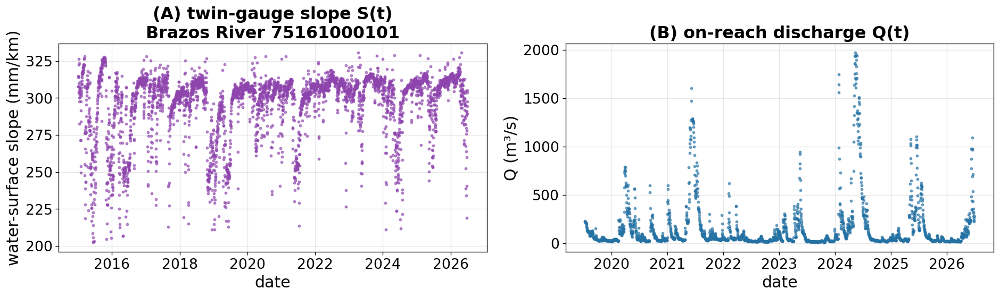

4124 paired daily records; slope pair 08114000->08116650 span 30.95 km; discharge gauge 08114100


In [3]:
# --- demo Step 1 on one reach: the twin-gauge slope S(t) and on-reach discharge Q(t) ---
_demo = next(r for r in ROWS.values() if r.gup and r.gdn and r.gmid)
_tw = twin_series(_demo)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(_tw.date, _tw.S*1e6, ".", ms=5, color="#8e44ad", alpha=.6)
ax[0].set_title(f"(A) twin-gauge slope S(t)\n{_demo.river} {_demo.reach}")
ax[0].set_ylabel("water-surface slope (mm/km)"); ax[0].set_xlabel("date")
ax[1].plot(_tw.date, _tw.discharge_cms, ".", ms=5, color="#2471a3", alpha=.6)
ax[1].set_title("(B) on-reach discharge Q(t)"); ax[1].set_ylabel("Q (m³/s)"); ax[1].set_xlabel("date")
fig.tight_layout(); plt.show()
_pr = getattr(_demo, "_pair", None); _dg = getattr(_demo, "_dg", None)
print(f"{len(_tw)} paired daily records; slope pair {_pr[0]}->{_pr[1]} span {_pr[2]} km; discharge gauge {_dg}")


## Step 2 · QC the `(S, Q)` cloud  &nbsp;·&nbsp;  Step 3 · Fit the relationship `S(Q)`

The **method engine** (inlined): `sq_pairs` builds the quality-checked `(Q, S)` cloud (positive-only, robust
MAD clip on log-slope and log-Q); `fit_sq` fits both a quadratic and a monotone power-law and keeps the higher
R². `inject_sq` / `_solve_Q` perform the iterative-Manning injection used in Step 4.

In [4]:
# ---- METHOD ENGINE (inlined) : S(Q) cloud, fit, iterative-Manning injection ----
def _fit_quadratic(Q, S):
    c = np.polyfit(Q, S, 2)                                        # S = c0 Q^2 + c1 Q + c2  (slides' form)
    f = lambda q, c=c: np.clip(np.polyval(c, np.asarray(q, float)), 1e-7, None)
    r2 = 1 - np.sum((S - f(Q))**2) / max(np.sum((S - S.mean())**2), 1e-12)
    lbl = f"S = {c[0]:.2e}Q² {c[1]:+.2e}Q {c[2]:+.2e}"
    return dict(func=f, kind="quadratic", r2=float(r2), params=c.tolist(), label=lbl)

def _fit_powerlaw(Q, S):
    from scipy.optimize import curve_fit
    (a, b, cc), _ = curve_fit(lambda q, a, b, cc: a*np.power(q, b)+cc, Q, S,
                              p0=[np.median(S), 0.3, 0.0], maxfev=10000)
    f = lambda q, a=a, b=b, cc=cc: np.clip(a*np.power(np.asarray(q, float), b)+cc, 1e-7, None)
    r2 = 1 - np.sum((S - f(Q))**2) / max(np.sum((S - S.mean())**2), 1e-12)
    lbl = f"S = {a:.2e}·Q^{b:.2f} {cc:+.2e}"
    return dict(func=f, kind="powerlaw", r2=float(r2), params=[a, b, cc], label=lbl)

def fit_sq(Q, S):
    """Fit S(Q); keep the better of quadratic (slides) and power-law by R². Q,S are 1-D arrays."""
    Q = np.asarray(Q, float); S = np.asarray(S, float)
    cands = []
    for fn in (_fit_quadratic, _fit_powerlaw):
        try: cands.append(fn(Q, S))
        except Exception: pass
    if not cands: return None
    best = max(cands, key=lambda d: d["r2"]); best["n"] = len(Q)
    best["Q_range"] = (float(np.min(Q)), float(np.max(Q))); best["S_range"] = (float(np.min(S)), float(np.max(S)))
    return best

def _solve_Q(q_orig, s_old, sfunc, q_lo, q_hi, iters=60, tol=1e-4):
    """Solve  Q = q_orig * sqrt( S(Q)/s_old )  by fixed-point iteration, S(Q) clamped to the fitted Q-range."""
    q = float(q_orig)
    for _ in range(iters):
        qc = min(max(q, q_lo), q_hi)                       # evaluate S only within the observed Q-support
        s_new = float(sfunc(qc))
        q2 = q_orig * np.sqrt(max(s_new, 1e-9) / max(s_old, 1e-9))
        if abs(q2 - q) <= tol * max(q2, 1.0): q = q2; break
        q = 0.5*(q + q2)                                   # damped update -> robust convergence
    return q, float(sfunc(min(max(q, q_lo), q_hi)))

def inject_sq(ht, feature_ids, fit):
    """Rewrite (discharge_cms, SLOPE) for the given feature_ids using the S(Q) fit + iterative Manning solve.
    Returns (ht_new, n_rows_changed). Rows outside the fit's Q-support use the nearest supported Q (clamped)."""
    ht = ht.copy(); fids = ht[FEAT].astype("int64"); sfunc = fit["func"]
    q_lo, q_hi = fit["Q_range"]; qcol = ht.columns.get_loc(Q_COL); scol = ht.columns.get_loc(SLOPE_COL)
    changed = 0
    for fid in set(int(f) for f in feature_ids):
        mask = (fids == fid).values
        if not mask.any(): continue
        idx = np.where(mask)[0]
        for i in idx:
            q_orig = float(ht.iloc[i, qcol]); s_old = float(ht.iloc[i, scol])
            if not (q_orig > 0 and s_old > 0): continue
            q_new, s_new = _solve_Q(q_orig, s_old, sfunc, q_lo, q_hi)
            ht.iloc[i, qcol] = q_new; ht.iloc[i, scol] = s_new; changed += 1
    return ht, changed

def swap_slope_timevarying(aoi_dir, feature_ids, fit):
    """Like fim_reach.swap_slope but injects the TIME-VARYING S(Q) SRC (iterative Manning) into every branch
    hydroTable for the reach's feature_ids (restores from the one-time .orig baseline so treatments don't
    compound). Returns the number of hydroTables rewritten."""
    import shutil
    wsd = Path(aoi_dir)/"watershed-data"; n = 0
    for ht in sorted((wsd/"branches").glob("*/hydroTable_*.csv")):
        orig = ht.with_name(ht.name + ".orig")
        if not orig.exists(): shutil.copy2(ht, orig)
        base = pd.read_csv(orig)
        base, _ = inject_sq(base, feature_ids, fit)
        base.to_csv(ht, index=False)
        ht.with_suffix(".parquet").unlink(missing_ok=True)      # generateFIM prefers parquet -> drop stale
        n += 1
    return n
print("method engine ready - sq_pairs / fit_sq / inject_sq inlined")

method engine ready - sq_pairs / fit_sq / inject_sq inlined


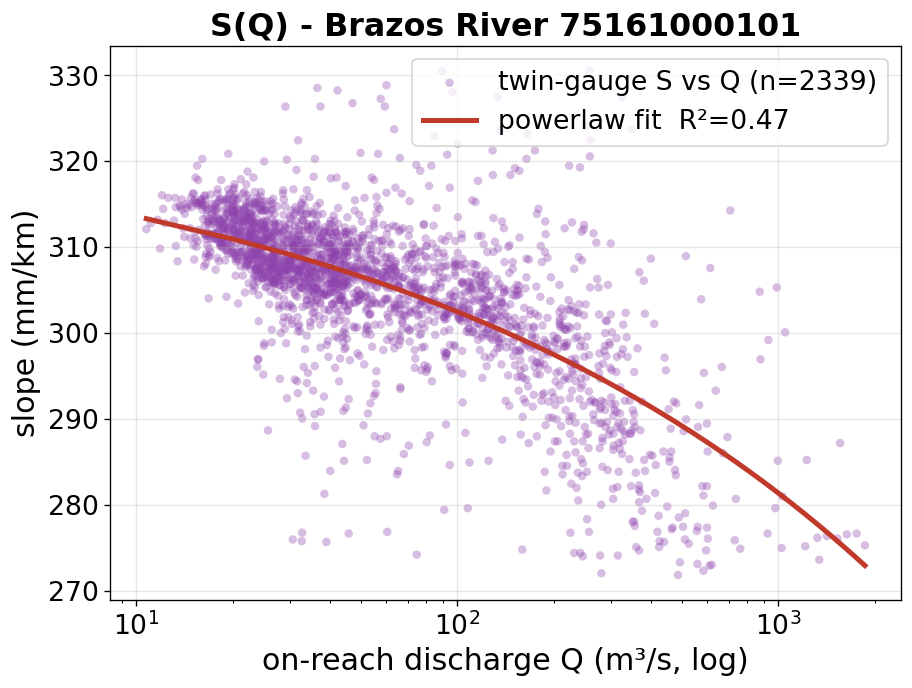

S = -6.42e-06·Q^0.28 +3.26e-04


In [5]:
# --- demo Steps 2-3 on the same reach: the (S,Q) cloud + the fitted S(Q) ---
def sq_for_row(row):
    "Generalized (Q,S) cloud for a reach; returns (pairs, discharge_gauge) or (None, None)."
    try: p = sq_pairs(row)
    except Exception: p = None
    return (p, getattr(row, "_dg", None)) if (p is not None and len(p) >= 8) else (None, None)

_p, _gq = sq_for_row(_demo); _fit = fit_sq(_p.Q_cms.values, _p.S.values)
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(_p.Q_cms, _p.S*1e6, s=26, color="#8e44ad", alpha=.35, ec="none", label=f"twin-gauge S vs Q (n={_fit['n']})")
_xf = np.linspace(*_fit["Q_range"], 200)
ax.plot(_xf, _fit["func"](_xf)*1e6, color="#c0392b", lw=3, label=f"{_fit['kind']} fit  R²={_fit['r2']:.2f}")
ax.set_xscale("log"); ax.set_xlabel("on-reach discharge Q (m³/s, log)"); ax.set_ylabel("slope (mm/km)")
ax.set_title(f"S(Q) - {_demo.river} {_demo.reach}"); ax.legend(loc="best"); plt.show()
print(_fit["label"])


## Step 4 · Iterative-Manning injection → time-varying SRC

The uncalibrated HAND SRC is `Q = G(h)·sqrt(S)`, with the geometry term `G(h) = Q_orig / sqrt(S_orig)` fixed by
the terrain. Replacing the constant slope by `S(Q)` makes the rating **flow-dependent**: at each stage we solve
the implicit `Q = Q_orig · sqrt(S(Q)/S_orig)` by damped fixed-point iteration (`_solve_Q`). Below we illustrate
the effect on a synthetic baseline geometry using the fitted `S(Q)`; Step 6 injects it into the real hydro-table.

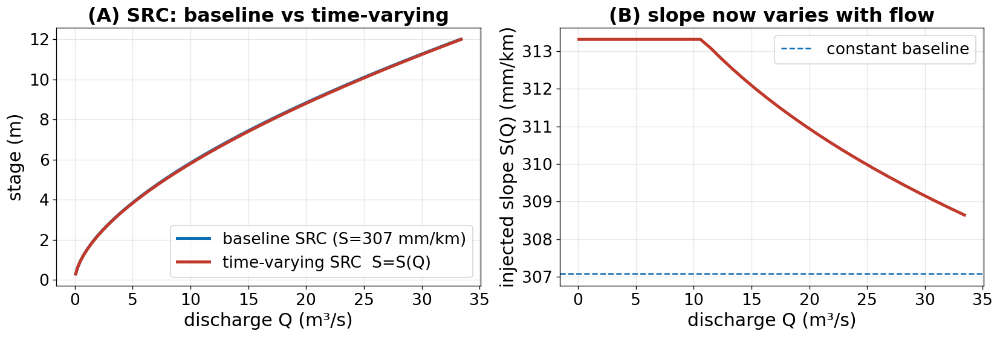

In [6]:
# --- demo Step 4: baseline (constant-slope) SRC vs time-varying SRC on a synthetic geometry ---
_s_base = float(np.median(_p.S))                          # a representative constant slope for the demo
_stage = np.linspace(0.3, 12, 40)
_G = 30.0 * _stage**1.67                                  # synthetic Manning geometry term (illustrative)
_q_base = _G * np.sqrt(_s_base)
_ql, _qh = _fit["Q_range"]; _q_tv, _s_tv = [], []
for q0 in _q_base:
    qn, sn = _solve_Q(float(q0), _s_base, _fit["func"], _ql, _qh); _q_tv.append(qn); _s_tv.append(sn*1e6)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(_q_base, _stage, color="#0f6fb5", lw=3, label=f"baseline SRC (S={_s_base*1e6:.0f} mm/km)")
ax[0].plot(_q_tv, _stage, color="#c0392b", lw=3, label="time-varying SRC  S=S(Q)")
ax[0].set_xlabel("discharge Q (m³/s)"); ax[0].set_ylabel("stage (m)"); ax[0].set_title("(A) SRC: baseline vs time-varying"); ax[0].legend()
ax[1].plot(_q_tv, _s_tv, color="#c0392b", lw=3); ax[1].axhline(_s_base*1e6, ls="--", color="#0f6fb5", label="constant baseline")
ax[1].set_xlabel("discharge Q (m³/s)"); ax[1].set_ylabel("injected slope S(Q) (mm/km)"); ax[1].set_title("(B) slope now varies with flow"); ax[1].legend()
fig.tight_layout(); plt.show()


## Step 5 · Fit `S(Q)` for **all** study reaches

Loop over the 50 reaches (using the cached `(S,Q)` clouds when present, else computing from NWIS). Reaches whose
gauges yield fewer than 8 valid paired records have no `S(Q)` and are flagged.

In [7]:
SQ = {}   # reach -> dict(pairs, fit, dg, pair, iris_mmkm)
summ = []
for r in ROWS.values():
    pf = PAIRS/f"{r.reach}.parquet"
    if pf.exists():
        p = sq_pairs(r) if False else pd.read_parquet(pf)   # cached generalized (Q,S) cloud
    else:
        p, _ = sq_for_row(r)
        if p is not None: p.to_parquet(pf)
    if p is None or len(p) < 8:
        summ.append(dict(reach=r.reach, river=r.river, status="no S(Q)", n=0)); continue
    fit = fit_sq(p.Q_cms.values, p.S.values); ism = iris_sword_mm(r.reach)
    _pm = pair_meta(r); pair = (_pm[0], _pm[1], _pm[2]) if _pm else None; dg = _pm[3] if _pm else None
    SQ[r.reach] = dict(pairs=p, fit=fit, dg=dg, pair=pair, iris_mmkm=ism)
    summ.append(dict(reach=r.reach, river=r.river, status="ok", n=len(p), kind=fit["kind"],
                     r2=round(fit["r2"],3), Smin_mmkm=round(fit["S_range"][0]*1e6,1),
                     Smax_mmkm=round(fit["S_range"][1]*1e6,1), iris_sword_mmkm=round(ism,1) if ism==ism else np.nan,
                     slope_pair=(f"{pair[0]}->{pair[1]}" if pair else ""), span_km=(pair[2] if pair else np.nan), dg=dg))
SQ_FITS = pd.DataFrame(summ)
SQ_FITS.to_csv(OUT/"sq_fits.csv", index=False)
print(f"{(SQ_FITS.status=='ok').sum()}/{len(SQ_FITS)} reaches with a usable S(Q) (generalized up>mid>dn pairing)")
SQ_FITS[SQ_FITS.status=="ok"].sort_values("r2", ascending=False).head(12)


46/50 reaches with a usable S(Q) (generalized up>mid>dn pairing)


,reach,river,status,n,kind,r2,Smin_mmkm,Smax_mmkm,iris_sword_mmkm,slope_pair,span_km,dg
6,74267300251,Ohio River,ok,3932,quadratic,0.989,587.4,3603.9,35.8,03293551->03294500,3.09,03294500
7,74267300261,Ohio River,ok,4002,quadratic,0.984,226.0,1327.0,61.0,03292494->03294500,8.46,03292494
22,75120500091,Sabine River,ok,2773,powerlaw,0.925,69.2,263.6,309.2,08030500->08030530,19.99,08030500
21,75120500081,Sabine River,ok,2773,powerlaw,0.925,69.2,263.6,11.6,08030500->08030530,19.99,08030500
40,73160100151,Susquehanna River,ok,4154,powerlaw,0.885,431.4,483.8,322.1,01570500->01576000,37.51,01570500
23,74222700141,Ouachita River,ok,2760,quadratic,0.881,2.6,72.3,0.0,07364535->07367005,22.01,07367005
20,71226700011,Red River Of The North,ok,3897,powerlaw,0.846,1.5,186.2,234.3,05070000->05082500,19.74,05082500
14,74267300241,Ohio River,ok,1257,powerlaw,0.771,7.5,98.5,132.3,03294500->03294560,18.49,03294500
41,73220500011,Great Pee Dee River,ok,1564,powerlaw,0.743,61.5,185.5,84.9,02131210->02135200,37.46,02135200
37,74293800021,Nishnabotna River,ok,4009,quadratic,0.689,360.9,413.7,148.8,06808500->06810000,30.72,06810000


## Deliverable 1 · Discharge–slope relationships `S(Q)` - 3×3 panels

Every reach with a usable `S(Q)`, nine per figure, in the work6 house style: the QC'd twin-gauge cloud (purple),
the best-fit `S(Q)` curve (red; quadratic or monotone power-law, whichever wins on R²) with its equation, and the
static **IRIS-SWORD** slope (blue dashed) for reference. One shared legend sits below each figure so nothing is
covered.

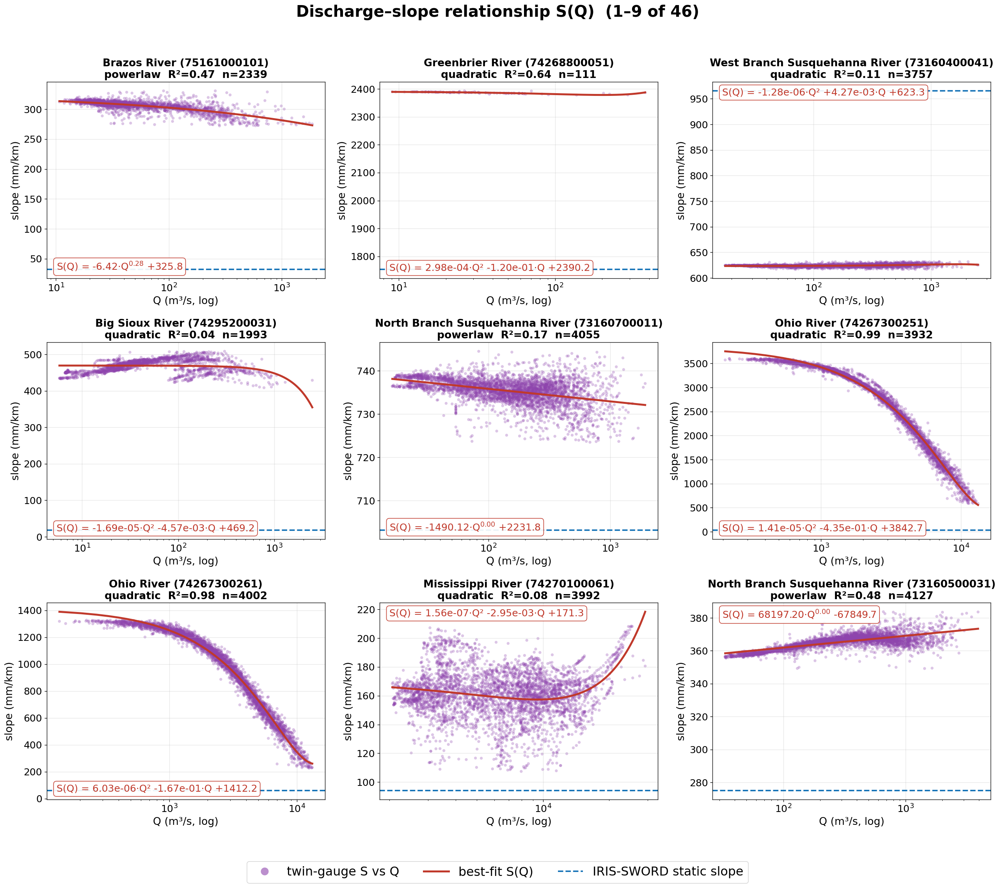

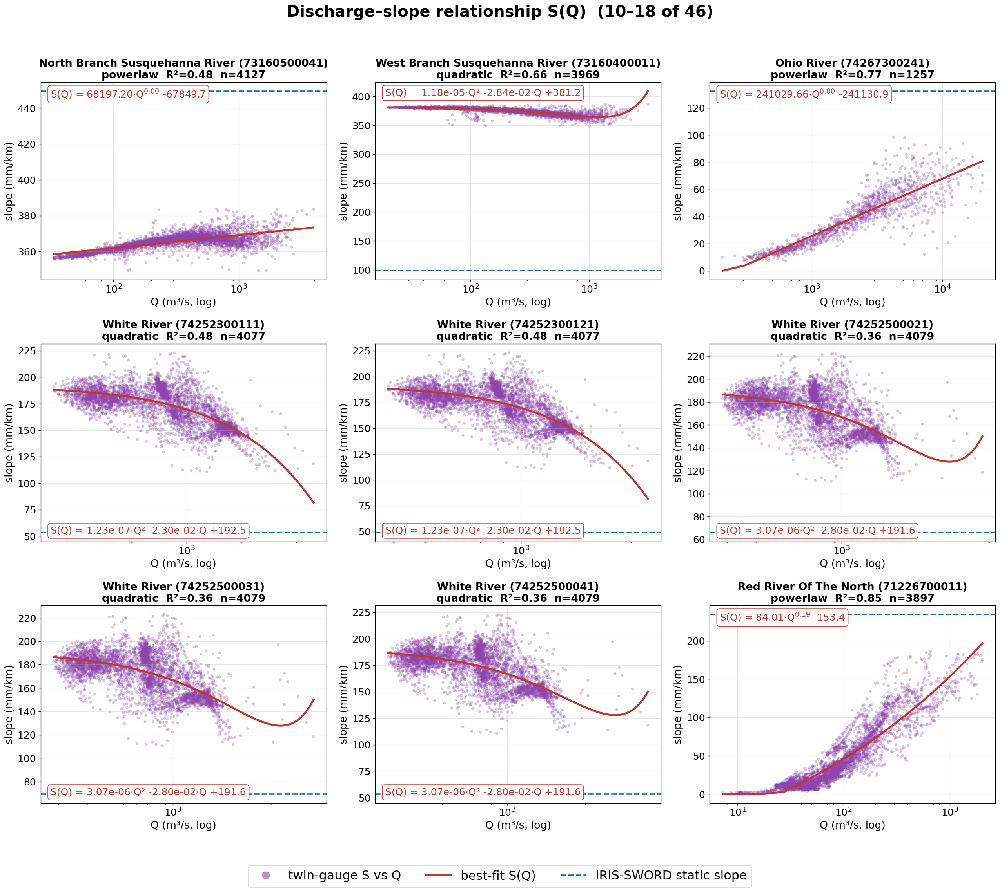

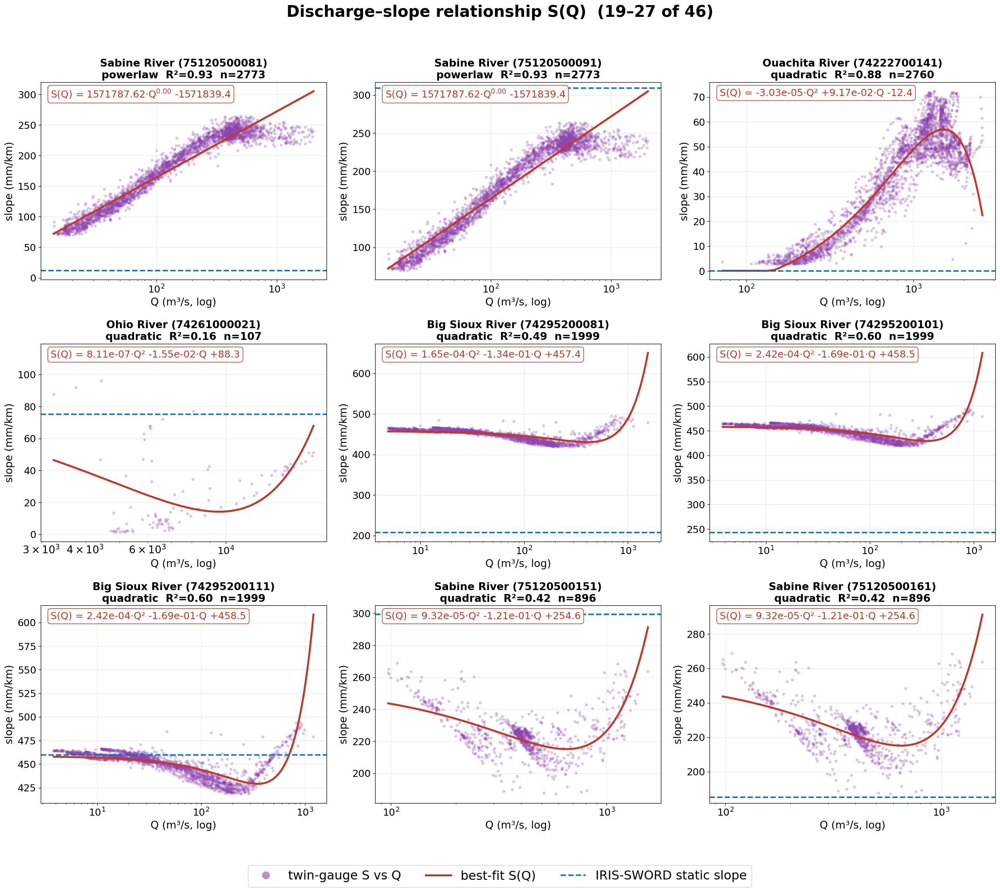

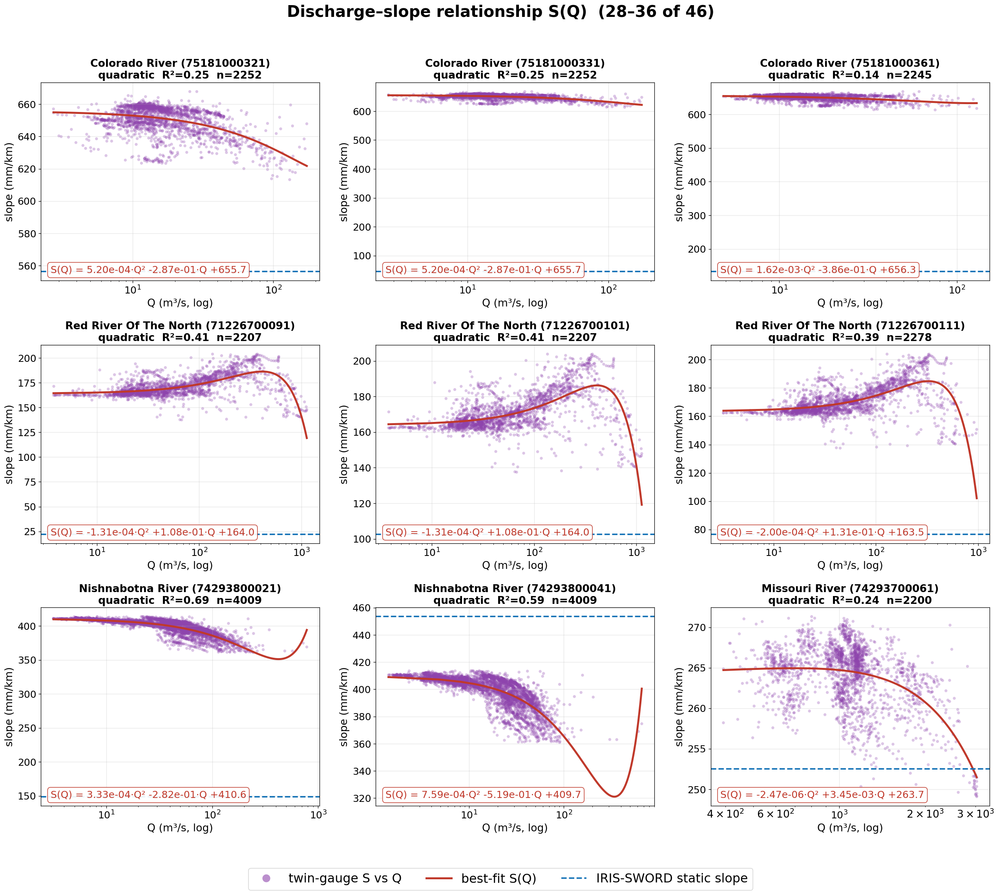

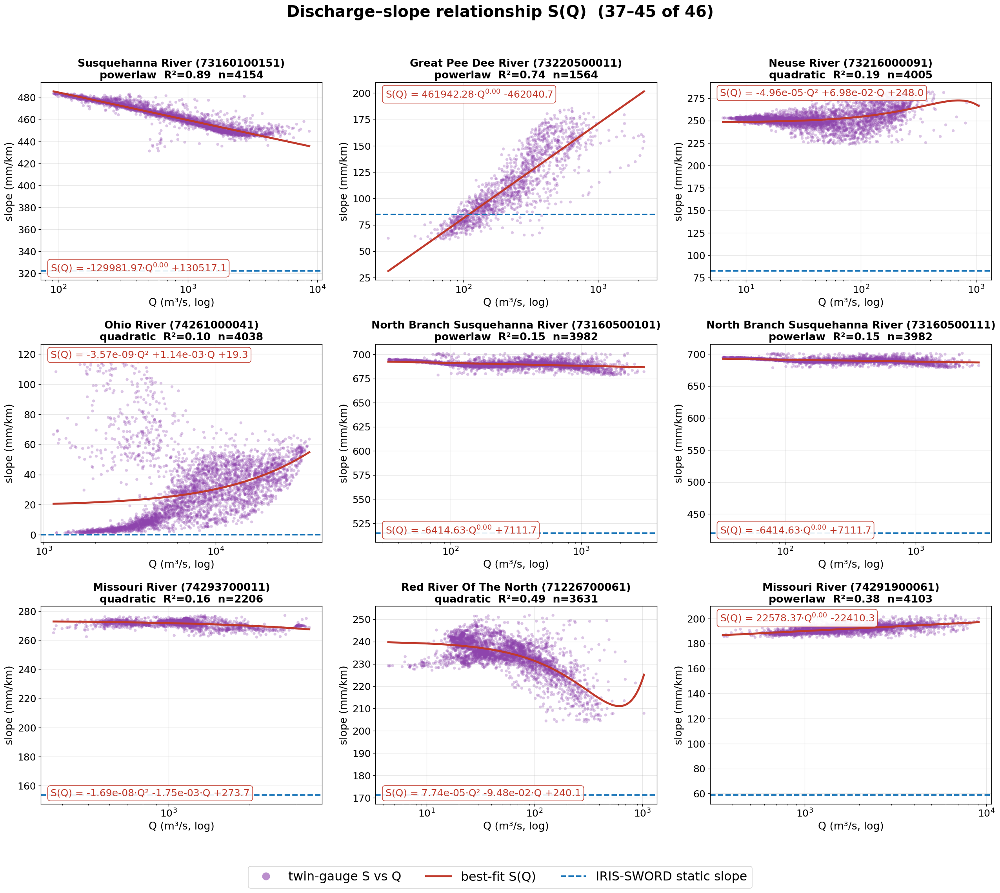

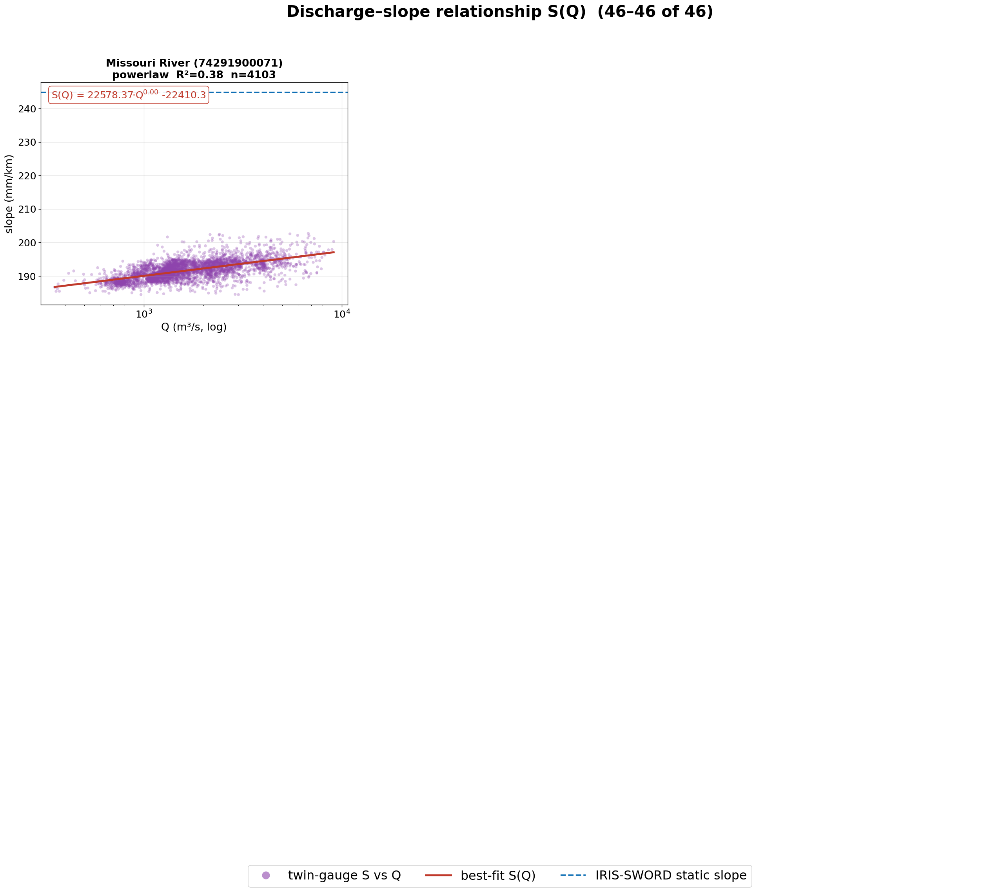

saved: ['sq_relationship_grid_1.png', 'sq_relationship_grid_2.png', 'sq_relationship_grid_3.png', 'sq_relationship_grid_4.png', 'sq_relationship_grid_5.png', 'sq_relationship_grid_6.png']


In [8]:
# ---- shared style + a 3x3 grid helper with ONE shared bottom legend (work6 house style) ----
TCOLOR = {"hydrofabric":"#7f8c8d", "iris_sword":"#0f6fb5", "gauge_timevarying":"#c0392b"}
TLABEL = {"hydrofabric":"hydrofabric", "iris_sword":"IRIS-SWORD", "gauge_timevarying":"gauge time-varying S(Q)"}
TSTYLE = {"hydrofabric":"-", "iris_sword":"--", "gauge_timevarying":"-."}

def grid_panels(items, draw, prefix, suptitle, legend_handles, ncols=3, nrows=3, per=(7.2, 6.2),
                legend_ncol=3, sup_fs=24):
    """Up to nrows*ncols panels per figure via draw(ax,item); ONE shared bottom legend; save prefix_k.png."""
    per_fig = ncols*nrows; paths = []
    for k in range(0, len(items), per_fig):
        chunk = items[k:k+per_fig]
        fig, axes = plt.subplots(nrows, ncols, figsize=(per[0]*ncols, per[1]*nrows))
        axes = np.atleast_1d(axes).ravel()
        for ax, it in zip(axes, chunk): draw(ax, it)
        for ax in axes[len(chunk):]: ax.axis("off")
        fig.suptitle(f"{suptitle}  ({k+1}–{k+len(chunk)} of {len(items)})", fontsize=sup_fs, y=1.005, fontweight="bold")
        fig.legend(handles=legend_handles, loc="lower center", ncol=legend_ncol,
                   bbox_to_anchor=(0.5, -0.012), fontsize=19, frameon=True)
        fig.tight_layout(rect=[0, 0.045, 1, 0.99])
        p = FIGS/f"{prefix}_{k//per_fig+1}.png"; savefig(fig, p); paths.append(p)
        plt.show()
    return paths

def _sq_equation(f):
    p = f["params"]
    if f["kind"] == "quadratic":
        c2, c1, c0 = [v*1e6 for v in p]; return f"S(Q) = {c2:.2e}·Q² {c1:+.2e}·Q {c0:+.1f}"
    a0, b0, c0 = p; return f"S(Q) = {a0*1e6:.2f}·Q$^{{{b0:.2f}}}$ {c0*1e6:+.1f}"

_sq_items = [(r, SQ[r]) for r in AREAS.reach if r in SQ]
def _draw_sq(ax, it):
    reach, d = it; p, fit = d["pairs"], d["fit"]; row = ROWS[reach]; ism = d.get("iris_mmkm", np.nan)
    ax.scatter(p.Q_cms, p.S*1e6, s=20, color="#8e44ad", alpha=.30, ec="none")
    xf = np.linspace(*fit["Q_range"], 200)
    ax.plot(xf, fit["func"](xf)*1e6, color="#c0392b", lw=3)
    if ism == ism:
        ax.axhline(ism, color="#0f6fb5", ls="--", lw=2.2)
    ax.set_xscale("log"); ax.set_xlabel("Q (m³/s, log)", fontsize=16); ax.set_ylabel("slope (mm/km)", fontsize=16)
    ax.set_title(f"{row.river} ({reach})\n{fit['kind']}  R²={fit['r2']:.2f}  n={fit['n']}", fontsize=16)
    # equation box in the least-busy corner (upper-left if the cloud trends up, else lower-left)
    up = fit["func"](fit["Q_range"][1]) >= fit["func"](fit["Q_range"][0])
    y0, va = (0.97, "top") if up else (0.03, "bottom")
    ax.text(0.035, y0, _sq_equation(fit), transform=ax.transAxes, ha="left", va=va, fontsize=15,
            color="#c0392b", bbox=dict(boxstyle="round", fc="white", ec="#c0392b", alpha=.92))
    ax.tick_params(labelsize=15)
_sq_legend = [Line2D([],[],marker="o",ls="",ms=12,mfc="#8e44ad",mec="none",alpha=.6,label="twin-gauge S vs Q"),
              Line2D([],[],color="#c0392b",lw=3,label="best-fit S(Q)"),
              Line2D([],[],color="#0f6fb5",lw=2.2,ls="--",label="IRIS-SWORD static slope")]
_sq_paths = grid_panels(_sq_items, _draw_sq, "sq_relationship_grid",
                        "Discharge–slope relationship S(Q)", _sq_legend, legend_ncol=3)
print("saved:", [p.name for p in _sq_paths])


## Step 6 · HAND-FIM pipeline (stage → HAND → inject slope → FIM → score)

The **FIM engine** (inlined from the project's HAND-FIM driver + FIM-eval metrics), plus a macOS-safe 3DEP DEM
fetch (clean subprocess). For each reach we stage its HUC once, build HAND once, then per slope **treatment**
rewrite the hydro-table slope and run FIMbox:

- **hydrofabric** - the uninjected HAND SRC (terrain slope),
- **iris_sword** - Chen et al. (2025) IRIS-SWORD static satellite slope (where available; SWORD-native fallback),
- **gauge_timevarying** - this study's `S(Q)` method.

**Evaluation domain - the River Mask.** FIMBench benchmarks are multi-source (optical / SAR / high-water-mark)
and deliberately capture the *largest* water extent: lakes, reservoirs, tributaries, and urban flooding that
HAND-FIM cannot represent. Scoring over the whole benchmark AOI drowns the reach-slope signal under huge
off-channel false-negatives. Following the team note *"River Mask for metric calculation"*, we therefore restrict
every metric to the **NWM catchments the reach's `feature_id`s belong to** (the reach's branch domain) and clean
the benchmark to its **largest connected flooded component** (dropping sensor-error blobs). CSI / F1 / POD / FAR
are computed on that masked domain - the region where the modelled slope can actually change the inundation.

**Fallback so every reach gets a result.** Some reaches carry sparse high-water-mark benchmarks whose wet pixels do
not fall inside the reach's NWM catchments, so the River-Mask domain is empty (undefined CSI). For those reaches we
**drop the River Mask** and score on a **5 km reach-centreline buffer** instead (benchmark still cleaned to its
largest connected component). Each scored reach therefore carries a `domain` label (`river_mask` or
`reach_buffer_5km`), so every reach with a FIM has a CSI / F1 while the River-Mask result is used wherever it is
defined.

**Operational data for out-of-retrospective floods.** The NWM retrospective ends 2023-01-31, so recent benchmarks
(e.g. Ohio 2025, Big Sioux 2024) fall outside it. For those reaches the FIM is driven by **operational / observed
USGS discharge** at the flood (the peak in the event window from the on-reach gauge), applied to the reach's
`feature_id`s via `from_discharge_inputs(csv=)` - a gauge-driven run that bypasses NWM. In-retrospective reaches
stay NWM-driven.

> **Architecture.** The Dask-based fimbox steps (HAND build + `generateFIM`) cannot run inside a Jupyter kernel on
> macOS (Dask's spawn workers re-import the module and hang without a `__main__` guard). The notebook therefore
> writes a self-contained `_fim_worker.py` and runs it per reach via subprocess; slope-swap, scoring, and all
> plotting stay in the notebook. The worker also **validates the staged 3DEP DEM and re-fetches it** if a transient
> download left it all-nodata (the usual cause of a "no stream cells / staging" failure). Heavy for 50 reaches
> across 18 HUCs - set env `TVS_REGEN=1` and `TVS_SUBSET=reach,reach` to generate a subset; otherwise cached
> scores load.

In [9]:
# ---- FIM-EVAL ENGINE (inlined; pure numpy/rasterio - safe to run in-notebook) ----
import geopandas as gpd, pyogrio, rasterio
from rasterio.warp import reproject, Resampling
from rasterio.features import geometry_mask
from shapely.geometry import box as _box
try:
    from fimbox._dask import _resolve_n_workers          # fimbox is only needed for FIM (re)generation (TVS_REGEN=1)
except Exception:
    def _resolve_n_workers(): return 2                        # cache-only analysis run: no fimbox required
FIMBOX_OUT = DATA/"fimbox_out"; FIMBOX_OUT.mkdir(parents=True, exist_ok=True)
EA = "EPSG:5070"

# reach<->feature_id + AOI-dir helpers (no Dask - fine in-notebook)
def reach_feature_ids(aoi_dir, reach_ids, tol_m=1000.0):
    """NWM feature_id(s) whose flowline is within tol_m of any given SWORD reach centerline.
    Returns a set of ints (== hydroTable feature_id). reach_ids: one id or an iterable."""
    if isinstance(reach_ids, (str, int)): reach_ids = [reach_ids]
    streams = Path(aoi_dir)/"watershed-data"/"baseline_subset_streams.gpkg"
    if not streams.exists():
        streams = next((Path(aoi_dir)/"watershed-data").glob("*_subset_streams.gpkg"), None)
    if streams is None: return set()
    nwm = pyogrio.read_dataframe(streams, columns=["ID"]).to_crs(5070)
    ids = set()
    for r in reach_ids:
        try:
            gg = pyogrio.read_dataframe(SWORD, where=f"reach_id = {int(r)}")
            if not len(gg): continue
            line = gg.set_crs(4326, allow_override=True).to_crs(5070).geometry.iloc[0]
            d = nwm.geometry.distance(line)               # robust distance query (avoids sjoin_nearest topology errors)
            ids |= set(nwm.loc[d <= tol_m, "ID"].astype("int64").tolist())
        except Exception: pass
    return ids

def _aoi_dir(huc8):
    huc8 = str(huc8).zfill(8)
    for c in [FIMBOX_OUT/f"HUC{huc8}"] + [p.parent for p in FIMBOX_OUT.glob(f"*{huc8}*/watershed-data")]:
        if (c/"watershed-data").is_dir(): return c
    return None

def _fully_staged(aoi):
    "True only if the streams file exists (a partial folder with just DEM/WBD is NOT fully staged)."
    return aoi is not None and bool(list((Path(aoi)/"watershed-data").glob("*_subset_streams.gpkg")))

def reach_buffer(reach_ids, buffer_km=5.0):
    """Union of `buffer_km` buffers around the SWORD centerline(s) of `reach_ids`, returned in EPSG:5070.
    This is the riverine evaluation domain: FIM benchmarks (esp. coastal HWM) cover huge basins that include
    storm-surge/pluvial water HAND-FIM cannot represent, so slope-sensitivity CSI must be scored near the
    modeled channel, not over the whole AOI."""
    if isinstance(reach_ids, (str, int)): reach_ids = [reach_ids]
    geoms = []
    for r in reach_ids:
        try:
            gg = pyogrio.read_dataframe(SWORD, where=f"reach_id = {int(r)}")
            if len(gg): geoms.append(gg.set_crs(4326, allow_override=True).to_crs(EA).geometry.iloc[0])
        except Exception: pass
    if not geoms: return None
    gs = gpd.GeoSeries(geoms, crs=EA).buffer(buffer_km*1000.0)
    return gs.union_all()

def _grid_for_aoi(aoi_gpkg, grid_m, clip_geom=None):
    """Target grid (transform, width, height, bounds) in EPSG:5070 covering the AOI, optionally intersected with
    clip_geom. `aoi_gpkg` may be a gpkg path, a GeoDataFrame, or a shapely geometry already in EPSG:5070."""
    if hasattr(aoi_gpkg, "geom_type"):                       # a shapely geometry in EPSG:5070 (e.g. the eval box)
        aoi = gpd.GeoDataFrame(geometry=[aoi_gpkg], crs=EA)
    elif isinstance(aoi_gpkg, gpd.GeoDataFrame):
        aoi = aoi_gpkg.to_crs(EA)
    else:
        aoi = pyogrio.read_dataframe(aoi_gpkg).to_crs(EA)
    if clip_geom is not None:
        aoi = gpd.GeoDataFrame(geometry=[aoi.union_all().intersection(clip_geom)], crs=EA)
        aoi = aoi[~aoi.geometry.is_empty]
    minx, miny, maxx, maxy = aoi.total_bounds
    minx = np.floor(minx/grid_m)*grid_m; miny = np.floor(miny/grid_m)*grid_m
    maxx = np.ceil(maxx/grid_m)*grid_m;  maxy = np.ceil(maxy/grid_m)*grid_m
    width = int(round((maxx-minx)/grid_m)); height = int(round((maxy-miny)/grid_m))
    transform = rasterio.transform.from_origin(minx, maxy, grid_m, grid_m)
    return aoi, transform, width, height, (minx, miny, maxx, maxy)

def _resample_to_grid(src_path, transform, width, height, band=1, resampling=Resampling.nearest):
    """Read `src_path`, reproject its band onto the target 5070 grid. Returns (data, src_nodata)."""
    with rasterio.open(src_path) as src:
        dst = np.full((height, width), np.nan, dtype="float32")
        reproject(source=rasterio.band(src, band), destination=dst,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transform, dst_crs=EA, resampling=resampling,
                  src_nodata=src.nodata, dst_nodata=np.nan)
        return dst, src.nodata

def score(fim_tif, bm_tif, aoi_gpkg, grid_m=30.0, min_depth=0.0, clip_geom=None, reach_ids=None, buffer_km=5.0):
    """Categorical scores of a FIM extent vs a FIMBench benchmark within the AOI (optionally restricted to a
    reach buffer). Pass reach_ids to auto-build the buffer, or clip_geom (5070) directly. Returns a dict with
    CSI/POD/FAR/bias, the contingency counts, and wet-area (km^2) for FIM and benchmark."""
    _aoi_ok = (not isinstance(aoi_gpkg, (str, Path))) or Path(aoi_gpkg).exists()   # geometry/GDF, or an existing gpkg
    if not (fim_tif and Path(fim_tif).exists() and Path(bm_tif).exists() and _aoi_ok):
        return dict(error="missing input", CSI=np.nan)
    if clip_geom is None and reach_ids is not None:
        clip_geom = reach_buffer(reach_ids, buffer_km)
    aoi, transform, width, height, _ = _grid_for_aoi(aoi_gpkg, grid_m, clip_geom=clip_geom)
    if width == 0 or height == 0:
        return dict(error="empty domain after clip", CSI=np.nan)
    aoi_mask = ~geometry_mask(aoi.geometry, out_shape=(height, width), transform=transform, invert=False)
    bm, bm_nd = _resample_to_grid(bm_tif, transform, width, height)         # 1 wet / 0 dry / nan outside
    fim, fim_nd = _resample_to_grid(fim_tif, transform, width, height)      # depth/extent
    bm_defined = np.isfinite(bm) & (bm != (bm_nd if bm_nd is not None else -9999))
    domain = aoi_mask & bm_defined
    wet_bm = domain & (bm >= 0.5)
    wet_fim = domain & np.isfinite(fim) & (fim != (fim_nd if fim_nd is not None else -9999)) & (fim > min_depth)
    TP = int((wet_fim & wet_bm).sum()); FP = int((wet_fim & ~wet_bm).sum())
    FN = int((~wet_fim & wet_bm).sum()); TN = int((~wet_fim & ~wet_bm & domain).sum())
    csi = TP/(TP+FP+FN) if (TP+FP+FN) else np.nan
    pod = TP/(TP+FN) if (TP+FN) else np.nan
    far = FP/(FP+TP) if (FP+TP) else np.nan
    f1 = 2*TP/(2*TP+FP+FN) if (2*TP+FP+FN) else np.nan     # F1 = 2*CSI/(1+CSI) (Dice); precision=1-FAR, recall=POD
    bias = (TP+FP)/(TP+FN) if (TP+FN) else np.nan
    px_km2 = (grid_m**2)/1e6
    return dict(CSI=round(csi, 4) if csi == csi else np.nan, F1=round(f1, 4) if f1 == f1 else np.nan,
                POD=round(pod, 4) if pod == pod else np.nan,
                FAR=round(far, 4) if far == far else np.nan, bias=round(bias, 4) if bias == bias else np.nan,
                TP=TP, FP=FP, FN=FN, TN=TN, n_domain=int(domain.sum()),
                fim_wet_km2=round(int(wet_fim.sum())*px_km2, 3), bm_wet_km2=round(int(wet_bm.sum())*px_km2, 3),
                grid_m=grid_m)

def score_grids(fim_tif, bm_tif, aoi_gpkg, grid_m=30.0, min_depth=0.0, clip_geom=None, reach_ids=None, buffer_km=5.0):
    """Like score() but also returns the categorical map (2=TP,1=FP,-1=FN,0=TN, nan outside domain) plus
    the 5070 transform - for plotting a hit/miss/false-alarm map."""
    if clip_geom is None and reach_ids is not None:
        clip_geom = reach_buffer(reach_ids, buffer_km)
    aoi, transform, width, height, bounds = _grid_for_aoi(aoi_gpkg, grid_m, clip_geom=clip_geom)
    aoi_mask = ~geometry_mask(aoi.geometry, out_shape=(height, width), transform=transform, invert=False)
    bm, bm_nd = _resample_to_grid(bm_tif, transform, width, height)
    fim, fim_nd = _resample_to_grid(fim_tif, transform, width, height)
    bm_defined = np.isfinite(bm) & (bm != (bm_nd if bm_nd is not None else -9999))
    domain = aoi_mask & bm_defined
    wet_bm = domain & (bm >= 0.5)
    wet_fim = domain & np.isfinite(fim) & (fim != (fim_nd if fim_nd is not None else -9999)) & (fim > min_depth)
    cat = np.full((height, width), np.nan, dtype="float32")
    cat[domain & ~wet_fim & ~wet_bm] = 0     # TN
    cat[domain & wet_fim & ~wet_bm] = 1      # FP false alarm
    cat[domain & ~wet_fim & wet_bm] = -1     # FN miss
    cat[domain & wet_fim & wet_bm] = 2       # TP hit
    m = score(fim_tif, bm_tif, aoi_gpkg, grid_m=grid_m, min_depth=min_depth, clip_geom=clip_geom)
    return cat, transform, bounds, m

from scipy import ndimage as _ndi

# ---- RIVER MASK evaluation (per "River Mask for metric calculation", team note) ----
# Evaluation domain = the RIVER MASK (union of the reach's NWM catchments), benchmark cleaned to its largest
# connected component; see the Step 6 markdown for the rationale (off-channel benchmark water HAND cannot map).

def river_mask(aoi, reach, pad_m=0.0):
    "Union of the NWM catchments whose ID is one of the reach's feature_ids (EPSG:5070). This is the domain."
    aoi = Path(aoi); fids = set(int(f) for f in reach_feature_ids(aoi, [reach]))
    if not fids: return None
    catf = aoi/"watershed-data"/"nwm_catchments_proj_subset.gpkg"
    if not catf.exists(): return None
    cat = pyogrio.read_dataframe(catf, columns=["ID"]).to_crs(EA)
    cat = cat[cat.ID.astype("int64").isin(fids)]
    if not len(cat): return None
    geom = cat.union_all()
    return geom.buffer(pad_m) if pad_m else geom

def _largest_cc(mask):
    "Keep only the largest connected True-component (drops benchmark sensor-error blobs)."
    if not mask.any(): return mask
    lab, n = _ndi.label(mask)
    if n <= 1: return mask
    sizes = _ndi.sum(mask, lab, range(1, n+1))
    return lab == (int(np.argmax(sizes)) + 1)

from rasterio.windows import from_bounds as _from_bounds, Window as _Window
from rasterio.warp import transform_bounds as _tbounds
from affine import Affine as _Affine
def _resample_win(src_path, transform, width, height, bounds):
    "Windowed + decimated read of just the mask region (memory-safe on giant 0.2 m benchmarks), then reproject."
    with rasterio.open(src_path) as src:
        try:
            sb = _tbounds(EA, src.crs, bounds[0], bounds[1], bounds[2], bounds[3])
            win = _from_bounds(*sb, transform=src.transform).intersection(_Window(0, 0, src.width, src.height))
        except Exception:
            return _resample_to_grid(src_path, transform, width, height)
        if win.width < 1 or win.height < 1: return np.full((height, width), np.nan, "float32"), src.nodata
        oh = int(min(win.height, height*4)) or 1; ow = int(min(win.width, width*4)) or 1
        arr = src.read(1, window=win, out_shape=(1, oh, ow)).astype("float32")
        wt = src.window_transform(win); arr_t = wt * _Affine.scale(win.width/ow, win.height/oh)
        dst = np.full((height, width), np.nan, "float32")
        reproject(arr, dst, src_transform=arr_t, src_crs=src.crs, dst_transform=transform, dst_crs=EA,
                  src_nodata=src.nodata, dst_nodata=np.nan, resampling=Resampling.nearest)
        return dst, src.nodata

def score_rm(fim_tif, bm_tif, mask_geom, grid_m=30.0, min_depth=0.0, largest_cc=True, return_grid=False):
    "River-mask metrics: domain = mask_geom (reach catchments); benchmark cleaned to its largest component."
    if not (fim_tif and Path(fim_tif).exists() and bm_tif and Path(bm_tif).exists() and mask_geom is not None):
        return (None,)*4 if return_grid else dict(CSI=np.nan)
    aoi, transform, width, height, bounds = _grid_for_aoi(mask_geom, grid_m)
    if width == 0 or height == 0: return (None,)*4 if return_grid else dict(CSI=np.nan)
    aoi_mask = ~geometry_mask(aoi.geometry, out_shape=(height, width), transform=transform, invert=False)
    bm, bm_nd = _resample_win(bm_tif, transform, width, height, bounds)       # windowed (giant-benchmark safe)
    fim, fim_nd = _resample_to_grid(fim_tif, transform, width, height)        # our FIM output is small
    bm_defined = np.isfinite(bm) & (bm != (bm_nd if bm_nd is not None else -9999))
    domain = aoi_mask & bm_defined
    wet_bm = domain & (bm >= 0.5)
    if largest_cc: wet_bm = _largest_cc(wet_bm)
    wet_fim = domain & np.isfinite(fim) & (fim != (fim_nd if fim_nd is not None else -9999)) & (fim > min_depth)
    TP = int((wet_fim & wet_bm).sum()); FP = int((wet_fim & ~wet_bm & domain).sum())
    FN = int((~wet_fim & wet_bm).sum()); TN = int((~wet_fim & ~wet_bm & domain).sum())
    csi = TP/(TP+FP+FN) if (TP+FP+FN) else np.nan; pod = TP/(TP+FN) if (TP+FN) else np.nan
    far = FP/(FP+TP) if (FP+TP) else np.nan; f1 = 2*TP/(2*TP+FP+FN) if (2*TP+FP+FN) else np.nan
    bias = (TP+FP)/(TP+FN) if (TP+FN) else np.nan; px = (grid_m**2)/1e6
    m = dict(CSI=round(csi,4) if csi==csi else np.nan, F1=round(f1,4) if f1==f1 else np.nan,
             POD=round(pod,4) if pod==pod else np.nan, FAR=round(far,4) if far==far else np.nan,
             bias=round(bias,4) if bias==bias else np.nan, TP=TP, FP=FP, FN=FN, TN=TN,
             n_domain=int(domain.sum()), fim_wet_km2=round(int(wet_fim.sum())*px,3),
             bm_wet_km2=round(int(wet_bm.sum())*px,3), grid_m=grid_m)
    if return_grid:
        cat = np.full((height, width), np.nan, dtype="float32")
        cat[domain & ~wet_fim & ~wet_bm] = 0; cat[domain & wet_fim & ~wet_bm] = 1
        cat[domain & ~wet_fim & wet_bm] = -1; cat[domain & wet_fim & wet_bm] = 2
        return cat, transform, bounds, m
    return m
print("FIM-eval engine ready - reach_feature_ids / river_mask / score_rm inlined (River-Mask evaluation)")

FIM-eval engine ready - reach_feature_ids / river_mask / score_rm inlined (River-Mask evaluation)


In [10]:
# ---- write the self-contained subprocess workers (FIM generation must run under a __main__ guard) ----
_DEM_WORKER_SRC = '"""Clean-subprocess 3DEP DEM fetcher - isolates py3dep/rasterio from pyogrio.\n\nOn macOS, fimbox reads boundaries with pyogrio, which corrupts the shared GDAL/PROJ global state so the\nsubsequent py3dep.get_dem (rasterio, remote COG read) SEGFAULTS. This worker imports NO pyogrio: it reads the\nboundary from a WKT file (shapely), grids the bbox into small safe boxes, fetches each 3DEP tile serially,\nmerges, clips, reprojects to the target CRS, conditions nodata, and writes the final DEM GeoTIFF. Run it as a\nfresh subprocess (see fim_reach._dem_run_subprocess) so GDAL starts clean.\n\nUsage: python fetch_dem_worker.py <boundary_wkt_file> <target_epsg> <resolution_m> <out_tif> [tile_deg]\n"""\nimport sys, warnings; warnings.filterwarnings("ignore")\nimport os; os.environ.pop("PROJ_DATA", None); os.environ.pop("PROJ_LIB", None)\nimport numpy as np\nfrom shapely import wkt as _wkt\nfrom shapely.geometry import box as _box\n\ndef main():\n    wkt_file, epsg, res, out_tif = sys.argv[1], int(sys.argv[2]), int(float(sys.argv[3])), sys.argv[4]\n    tile_deg = float(sys.argv[5]) if len(sys.argv) > 5 else 0.2\n    import py3dep, rioxarray\n    from rioxarray.merge import merge_arrays\n    from rasterio.enums import Resampling\n    from rasterio.fill import fillnodata\n    boundary = _wkt.loads(open(wkt_file).read())\n    minx, miny, maxx, maxy = boundary.bounds\n    ov = res * 5 / 111_320.0\n    cells = [_box(x-ov, y-ov, min(x+tile_deg, maxx)+ov, min(y+tile_deg, maxy)+ov)\n             for y in np.arange(miny, maxy, tile_deg) for x in np.arange(minx, maxx, tile_deg)]\n    cells = [c for c in cells if c.intersects(boundary)]\n    print(f"[dem_worker] {len(cells)} boxes @ {tile_deg} deg, res {res}m -> {out_tif}", flush=True)\n    arrs = []\n    for i, g in enumerate(cells):\n        try:\n            arrs.append(py3dep.get_dem(geometry=g, resolution=res, crs=4326))\n        except Exception as e:\n            print(f"[dem_worker]  box {i+1} failed: {str(e)[:70]}", flush=True)\n        if (i+1) % max(1, len(cells)//10) == 0 or i+1 == len(cells):\n            print(f"[dem_worker]  {i+1}/{len(cells)}", flush=True)\n    if not arrs:\n        print("[dem_worker] ERROR: all boxes failed", flush=True); sys.exit(2)\n    dem = merge_arrays(arrs) if len(arrs) > 1 else arrs[0]\n    dem = dem.rio.clip([boundary], crs=4326, drop=True, all_touched=True)          # clip in WGS84\n    dem = dem.rio.reproject(f"EPSG:{epsg}", resolution=res, resampling=Resampling.bilinear)\n    # heal thin interior nodata seams (as fimbox does) before flow routing\n    try:\n        band = dem.values[0] if dem.values.ndim == 3 else dem.values\n        mask = np.isfinite(band) & (band > -90000)\n        healed = fillnodata(band.astype("float32"), mask=mask.astype("uint8"), max_search_distance=5)\n        if dem.values.ndim == 3: dem.values[0] = healed\n        else: dem.values = healed\n    except Exception as e:\n        print(f"[dem_worker] heal skipped: {str(e)[:60]}", flush=True)\n    dem = dem.where(dem > -90000, -999999); dem.rio.write_nodata(-999999, inplace=True)\n    dem.rio.to_raster(out_tif, driver="GTiff", compress="lzw", tiled=True, blockxsize=256, blockysize=256)\n    print(f"[dem_worker] DONE -> {out_tif}", flush=True)\n\nif __name__ == "__main__":\n    main()\n'
_FIM_WORKER_SRC = '"""Self-contained FIM worker (written by timevary_slope.ipynb).\nThe Dask-based fimbox steps (HAND build + generateFIM) MUST run in a process with an `if __name__=="__main__"`\nguard - Dask\'s spawn workers re-import the module, which hangs/errors inside a Jupyter kernel on macOS. So the\nnotebook delegates staging + HAND + slope-swap + FIM to this script via subprocess. Usage:\n    python _fim_worker.py <job.json> <result.json>\njob = {reach, huc8, event_date, fimcache, dem_worker, treatments:[{name, slope_mm?|fit?}]}"""\nimport warnings; warnings.filterwarnings("ignore")\nimport os; os.environ.pop("PROJ_DATA", None); os.environ.pop("PROJ_LIB", None)\nimport sys, json, glob, shutil, subprocess as _subprocess\nfrom pathlib import Path\nimport numpy as np, pandas as pd\nimport geopandas as gpd, pyogrio, fimbox\n\nROOT = Path(os.environ.get("SLOPE_ROOT") or Path.cwd()); DATA = ROOT/"data"\nSWORD = DATA/"SWORD_v17b_gpkg"/"na_sword_reaches_v17b.gpkg"\nFIMBOX_OUT = DATA/"fimbox_out"; FIMBOX_OUT.mkdir(parents=True, exist_ok=True)\nFEAT, SLOPE_COL, Q_COL = "feature_id", "SLOPE", "discharge_cms"\n_NW = 2\n_DEM_WORKER = FIMBOX_OUT/"_fetch_dem_worker.py"\n\ndef _dem_run_patched(self):\n    from fimbox._skip_if_valid import should_skip\n    from shapely import wkt as _wkt\n    save_path = self.output_dir / (self.out_name or ("processed_local_dem.tif" if self.dem_file else f"3dep_dem_{self.resolution}m.tif"))\n    if should_skip(save_path): return str(save_path)\n    if self.dem_file: return _DEM_RUN_ORIG(self)\n    wkt_file = self.output_dir/"_dem_boundary.wkt"; wkt_file.write_text(_wkt.dumps(self.boundary_geom))\n    try:\n        r = _subprocess.run([sys.executable, str(_DEM_WORKER), str(wkt_file), str(self.target_crs), str(self.resolution), str(save_path), "0.2"], capture_output=True, text=True, timeout=720)\n    except _subprocess.TimeoutExpired:\n        raise RuntimeError("3DEP DEM fetch timed out (720s) - 3DEP service slow/unavailable for this HUC")\n    if not save_path.exists(): raise RuntimeError("3DEP subprocess DEM fetch failed.\\n" + (r.stdout or "")[-500:] + (r.stderr or "")[-300:])\n    return str(save_path)\ntry:\n    from fimbox.preprocessing.download_data.dem_process import DEMProcessor as _DEMP\n    _DEM_RUN_ORIG = _DEMP.run; _DEMP.run = _dem_run_patched; _DEMP.max_workers = 1\nexcept Exception as _e: print("DEM patch not applied:", _e, flush=True)\n\ndef reach_feature_ids(aoi_dir, reach_ids, tol_m=1000.0):\n    """NWM feature_id(s) whose flowline is within tol_m of any given SWORD reach centerline.\n    Returns a set of ints (== hydroTable feature_id). reach_ids: one id or an iterable."""\n    if isinstance(reach_ids, (str, int)): reach_ids = [reach_ids]\n    streams = Path(aoi_dir)/"watershed-data"/"baseline_subset_streams.gpkg"\n    if not streams.exists():\n        streams = next((Path(aoi_dir)/"watershed-data").glob("*_subset_streams.gpkg"), None)\n    if streams is None: return set()\n    nwm = pyogrio.read_dataframe(streams, columns=["ID"]).to_crs(5070)\n    ids = set()\n    for r in reach_ids:\n        try:\n            gg = pyogrio.read_dataframe(SWORD, where=f"reach_id = {int(r)}")\n            if not len(gg): continue\n            line = gg.set_crs(4326, allow_override=True).to_crs(5070).geometry.iloc[0]\n            d = nwm.geometry.distance(line)               # robust distance query (avoids sjoin_nearest topology errors)\n            ids |= set(nwm.loc[d <= tol_m, "ID"].astype("int64").tolist())\n        except Exception: pass\n    return ids\n\ndef _inject_hydrotable_df(ht, slope_map):\n    """SLOPE := S_new and discharge_cms *= sqrt(S_new/S_old) for every feature_id in slope_map.\n    The uncalibrated SRC is pure Manning (Q ~ sqrt(SLOPE)), so this equals rebuilding the SRC at S_new."""\n    ht = ht.copy(); fids = ht[FEAT].astype("int64")\n    qcol = ht.columns.get_loc(Q_COL); scol = ht.columns.get_loc(SLOPE_COL); changed = 0\n    for fid, s_new in slope_map.items():\n        mask = (fids == fid).values\n        if not mask.any(): continue\n        s_old = ht.loc[mask, SLOPE_COL].values; sn = np.full(mask.sum(), float(s_new))\n        ok = (s_old > 0) & (sn > 0)\n        if not ok.any(): continue\n        idx = np.where(mask)[0][ok]\n        ht.iloc[idx, qcol] = ht.iloc[idx, qcol].values * np.sqrt(sn[ok]/s_old[ok])\n        ht.iloc[idx, scol] = sn[ok]; changed += int(ok.sum())\n    return ht, changed\n\ndef _aoi_dir(huc8):\n    huc8 = str(huc8).zfill(8)\n    for c in [FIMBOX_OUT/f"HUC{huc8}"] + [p.parent for p in FIMBOX_OUT.glob(f"*{huc8}*/watershed-data")]:\n        if (c/"watershed-data").is_dir(): return c\n    return None\n\ndef _fully_staged(aoi):\n    "True only if the streams file exists (a partial folder with just DEM/WBD is NOT fully staged)."\n    return aoi is not None and bool(list((Path(aoi)/"watershed-data").glob("*_subset_streams.gpkg")))\n\ndef stage(huc8):\n    """Download DEM/NWM/gages for the HUC once (cached). Returns the AOI working dir. Re-runs getAllInputData\n    when the folder is only PARTIAL (e.g. DEM staged but flowlines/catchments missing) - getAllInputData\n    skips the already-valid DEM, so this just completes the missing streams/catchments."""\n    huc8 = str(huc8).zfill(8)\n    aoi = _aoi_dir(huc8)\n    if _fully_staged(aoi): return aoi\n    fimbox.getAllInputData(huc8=huc8, out_dir=str(FIMBOX_OUT), buffer_m=2000, headwater_buffer_cells=8,\n                           get_flowlines=True, get_catchments=True, resolution="medium", identifier="nwm").run()\n    return _aoi_dir(huc8)\n\ndef build_hand_once(aoi_dir):\n    """BranchDerivation + HAND/SRC for every branch - the HEAVY step, ONCE per HUC (cached when branch\n    hydroTables already exist). Slope here is a placeholder swapped per-reach later. NO calibration.\n    If fimbox\'s levee-association step hits a GEOS topology error, the levee gpkgs are hidden and the build\n    is retried without levees (some NLD levee geometries are self-intersecting and crash single-sided buffer)."""\n    wsd = Path(aoi_dir)/"watershed-data"\n    if list((wsd/"branches").glob("*/hydroTable_*.csv")): return False\n    ident = next(wsd.glob("*_subset_streams.gpkg")).name.split("_subset_streams")[0]\n    _opt = lambda p: p if p.exists() else None\n    def _run():\n        fimbox.BranchDerivation(out_dir=wsd, branch_id_attribute="levpa_id", reach_id_attribute="ID",\n                                branch_buffer_distance_meters=7000.0).run()\n        cfg = fimbox.AOIProcessingConfig(\n            aoi_dir=wsd, branch_list_path=wsd/"branch_ids.lst", dem_path=wsd/"dem.tif",\n            streams_gpkg=wsd/f"{ident}_subset_streams.gpkg", boundary_gpkg=wsd/"wbd_buffered.gpkg",\n            bridge_elev_diff_path=_opt(wsd/"bridge_elev_diff.tif"),\n            levee_gpkg_path=_opt(wsd/"3d_nld_subset_levees_burned.gpkg"),\n            headwaters_gpkg=_opt(wsd/f"{ident}_headwaters.gpkg"),\n            levelpaths_extended_gpkg=_opt(wsd/f"{ident}_subset_streams_levelPaths_extended.gpkg"),\n            mannings_n=0.06, stage_min_m=0.0, stage_interval_m=0.3048, stage_max_m=25.2984,\n            min_catchment_area=0.25, min_stream_length=0.5, crosswalk_max_distance_m=100.0,\n            src_slope_source="iris_sword", iris_slope_csv=None,\n            n_workers=_NW, keep_failed_branches=True, delete_deny_list=True)\n        fimbox.calculate_allbranches(cfg, run_branch_zero=True, branch_ids_csv=wsd/"branch_ids.csv")\n    try:\n        _run()\n    except Exception as e:\n        msg = str(e).lower()\n        if "non-noded" in msg or "topology" in msg or "levee" in msg:      # fimbox NLD-levee GEOS bug -> drop levees, retry\n            for lv in list(wsd.glob("*levee*.gpkg")) + list(wsd.glob("*nld*.gpkg")):\n                try: lv.rename(lv.with_suffix(".gpkg.disabled"))\n                except Exception: pass\n            shutil.rmtree(wsd/"branches", ignore_errors=True)\n            _run()\n        else:\n            raise\n    return True\n\ndef swap_slope(aoi_dir, slope_map):\n    """Inject slope into every branch hydroTable by the exact Manning rescale (restores from a one-time\n    .orig baseline so treatments don\'t compound). slope_map={feature_id: m/m}; empty -> baseline restored."""\n    wsd = Path(aoi_dir)/"watershed-data"; n = 0\n    for ht in sorted((wsd/"branches").glob("*/hydroTable_*.csv")):\n        orig = ht.with_name(ht.name + ".orig")\n        if not orig.exists(): shutil.copy2(ht, orig)\n        base = pd.read_csv(orig)\n        if slope_map: base, _ = _inject_hydrotable_df(base, slope_map)\n        base.to_csv(ht, index=False)\n        ht.with_suffix(".parquet").unlink(missing_ok=True)   # generateFIM prefers parquet -> drop stale\n        n += 1\n    return n\n\ndef _run_fim(aoi_dir, event_date):\n    """NWM retrospective discharge for the event -> generateFIM -> newest inundation-extent raster."""\n    aoi_dir = Path(aoi_dir)\n    day = pd.to_datetime(event_date).strftime("%Y-%m-%d")\n    vt = pd.to_datetime(event_date).strftime("%Y-%m-%d %H:00:00")\n    fimbox.getNWMretrospective(aoi_dir, date=vt)\n    res = fimbox.generateFIM(aoi_dir, n_workers=_NW, depth=True).from_discharge_inputs(date=day)\n    exts = [getattr(r, "extent_path", None) for r in (res or [])]\n    exts = [Path(e) for e in exts if e]\n    if exts: return exts[-1]\n    tifs = sorted((aoi_dir/"fim-outputs").glob("*inundation*.tif"), key=lambda p: p.stat().st_mtime)\n    return tifs[-1] if tifs else None\n\ndef _solve_Q(q_orig, s_old, sfunc, q_lo, q_hi, iters=60, tol=1e-4):\n    """Solve  Q = q_orig * sqrt( S(Q)/s_old )  by fixed-point iteration, S(Q) clamped to the fitted Q-range."""\n    q = float(q_orig)\n    for _ in range(iters):\n        qc = min(max(q, q_lo), q_hi)                       # evaluate S only within the observed Q-support\n        s_new = float(sfunc(qc))\n        q2 = q_orig * np.sqrt(max(s_new, 1e-9) / max(s_old, 1e-9))\n        if abs(q2 - q) <= tol * max(q2, 1.0): q = q2; break\n        q = 0.5*(q + q2)                                   # damped update -> robust convergence\n    return q, float(sfunc(min(max(q, q_lo), q_hi)))\n\ndef inject_sq(ht, feature_ids, fit):\n    """Rewrite (discharge_cms, SLOPE) for the given feature_ids using the S(Q) fit + iterative Manning solve.\n    Returns (ht_new, n_rows_changed). Rows outside the fit\'s Q-support use the nearest supported Q (clamped)."""\n    ht = ht.copy(); fids = ht[FEAT].astype("int64"); sfunc = fit["func"]\n    q_lo, q_hi = fit["Q_range"]; qcol = ht.columns.get_loc(Q_COL); scol = ht.columns.get_loc(SLOPE_COL)\n    changed = 0\n    for fid in set(int(f) for f in feature_ids):\n        mask = (fids == fid).values\n        if not mask.any(): continue\n        idx = np.where(mask)[0]\n        for i in idx:\n            q_orig = float(ht.iloc[i, qcol]); s_old = float(ht.iloc[i, scol])\n            if not (q_orig > 0 and s_old > 0): continue\n            q_new, s_new = _solve_Q(q_orig, s_old, sfunc, q_lo, q_hi)\n            ht.iloc[i, qcol] = q_new; ht.iloc[i, scol] = s_new; changed += 1\n    return ht, changed\n\ndef swap_slope_timevarying(aoi_dir, feature_ids, fit):\n    """Like fim_reach.swap_slope but injects the TIME-VARYING S(Q) SRC (iterative Manning) into every branch\n    hydroTable for the reach\'s feature_ids (restores from the one-time .orig baseline so treatments don\'t\n    compound). Returns the number of hydroTables rewritten."""\n    import shutil\n    wsd = Path(aoi_dir)/"watershed-data"; n = 0\n    for ht in sorted((wsd/"branches").glob("*/hydroTable_*.csv")):\n        orig = ht.with_name(ht.name + ".orig")\n        if not orig.exists(): shutil.copy2(ht, orig)\n        base = pd.read_csv(orig)\n        base, _ = inject_sq(base, feature_ids, fit)\n        base.to_csv(ht, index=False)\n        ht.with_suffix(".parquet").unlink(missing_ok=True)      # generateFIM prefers parquet -> drop stale\n        n += 1\n    return n\n\ndef _save_src(aoi, reach, name, fids, fimcache):\n    "Mean stage-discharge curve for the reach\'s feature_ids from the (just-injected) branch hydroTables."\n    hts = glob.glob(str(Path(aoi)/"watershed-data"/"branches"/"*"/"hydroTable_*.csv"))\n    fset = set(int(f) for f in fids)\n    frames = []\n    for h in hts:\n        try:\n            d = pd.read_csv(h, usecols=["feature_id", "stage", "discharge_cms", "SLOPE"])\n            frames.append(d[d.feature_id.isin(fset)])\n        except Exception: pass\n    if not frames: return\n    df = pd.concat(frames)\n    if not len(df): return\n    g = df.groupby("stage", as_index=False).agg(discharge_cms=("discharge_cms", "mean"), SLOPE=("SLOPE", "mean"))\n    g["stage0"] = g.stage - g.stage.min()\n    g.to_csv(Path(fimcache)/f"reach{reach}_{name}_src.csv", index=False)\n\ndef _rebuild_fit(spec):\n    kind, p = spec["kind"], spec["params"]; ql, qh = spec["Q_range"]\n    if kind == "quadratic":\n        f = lambda q, p=p: np.clip(np.polyval(p, np.asarray(q, float)), 1e-7, None)\n    else:\n        a, b, c = p; f = lambda q, a=a, b=b, c=c: np.clip(a*np.power(np.asarray(q, float), b)+c, 1e-7, None)\n    return dict(func=f, kind=kind, params=p, Q_range=(ql, qh))\n\ndef _dem_ok(aoi):\n    "True if the staged DEM has real elevation data (guards against a transient 3DEP all-nodata fetch)."\n    import rasterio\n    dem = Path(aoi)/"watershed-data"/"dem.tif"\n    if not dem.exists(): return False\n    try:\n        with rasterio.open(dem) as s:\n            a = s.read(1, out_shape=(1, min(400, s.height), min(400, s.width))).astype("float64"); nd = s.nodata\n            v = np.isfinite(a) & (a != (nd if nd is not None else -999999)) & (a > -90000)\n            return float(v.mean()) > 0.05\n    except Exception: return False\n\ndef _restage_dem(huc, aoi):\n    "Delete a bad DEM (+ its HAND products) and re-run staging so the DEM is re-fetched (fixes bad-DEM failures)."\n    wsd = Path(aoi)/"watershed-data"\n    for pat in ["dem.tif", "*3dep*dem*.tif", "processed_local_dem.tif", "hydro_conditioned*.tif", "_dem_boundary.wkt"]:\n        for f in wsd.glob(pat):\n            try: f.unlink()\n            except Exception: pass\n    shutil.rmtree(wsd/"branches", ignore_errors=True)                 # HAND built on the bad DEM -> rebuild\n    fimbox.getAllInputData(huc8=str(huc).zfill(8), out_dir=str(FIMBOX_OUT), buffer_m=2000,\n                           headwater_buffer_cells=8, get_flowlines=True, get_catchments=True,\n                           resolution="medium", identifier="nwm").run()\n    return _aoi_dir(str(huc).zfill(8)) or aoi\n\ndef _run_fim_gauge(aoi, fids, discharge_cms):\n    "Drive FIM from OPERATIONAL/observed discharge on the reach\'s feature_ids (for out-of-NWM-retrospective floods)."\n    ddir = Path(aoi)/"discharge-inputs"; ddir.mkdir(parents=True, exist_ok=True)\n    fq = ddir/"operational_flood.csv"\n    pd.DataFrame({"feature_id": sorted(int(f) for f in fids), "discharge_cms": float(discharge_cms)}).to_csv(fq, index=False)\n    fimbox.generateFIM(aoi, n_workers=_NW, depth=True).from_discharge_inputs(csv=str(fq))\n    exts = sorted((Path(aoi)/"fim-outputs").glob("*inundation*.tif"), key=lambda p: p.stat().st_mtime)\n    return exts[-1] if exts else None\n\ndef main():\n    job = json.load(open(sys.argv[1])); resf = sys.argv[2]\n    reach, huc, date = job["reach"], str(job["huc8"]).split(";")[0], job["event_date"]\n    q_op = job.get("discharge_cms")                                    # operational discharge -> gauge-driven FIM\n    out = dict(reach=reach, treatments={})\n    aoi = stage(huc)\n    if aoi is None: out["error"] = "stage_failed"; json.dump(out, open(resf, "w")); return\n    if not _dem_ok(aoi):                                               # transient bad-DEM staging -> re-fetch once\n        print(f"[worker] {reach}: staged DEM invalid, re-fetching...", flush=True)\n        try: aoi = _restage_dem(huc, aoi)\n        except Exception as e: out["dem_refetch_error"] = str(e)[:120]\n        if not _dem_ok(aoi): out["error"] = "dem_invalid_after_refetch"; json.dump(out, open(resf, "w")); return\n    # resolve feature_ids BEFORE the heavy HAND build: the fimbox Dask/pyogrio ops corrupt in-process GDAL/PROJ\n    # state and make the SWORD read silently return empty; computing it early keeps the state clean.\n    fids = sorted(int(f) for f in reach_feature_ids(aoi, [reach], tol_m=1500.0))\n    out["aoi"] = str(aoi); out["feature_ids"] = fids; out["driver"] = "gauge" if q_op else "nwm"\n    if not fids: out["error"] = "no_feature_ids"; json.dump(out, open(resf, "w")); return\n    build_hand_once(aoi)                                               # heavy: only after we know the reach maps to NWM ids\n    fids = sorted(int(f) for f in reach_feature_ids(aoi, [reach], tol_m=1500.0)) or fids   # refresh vs branch streams\n    for t in job["treatments"]:\n        name = t["name"]\n        try:\n            if name == "gauge_timevarying":  swap_slope_timevarying(aoi, fids, _rebuild_fit(t["fit"]))\n            elif t.get("slope_mm"):          swap_slope(aoi, {f: float(t["slope_mm"])/1e6 for f in fids})\n            else:                            swap_slope(aoi, {})\n            _save_src(aoi, reach, name, fids, Path(job["fimcache"]))     # per-treatment SRC (before next swap overwrites)\n            ext = _run_fim_gauge(aoi, fids, q_op) if q_op else _run_fim(aoi, date)\n            dest = Path(job["fimcache"])/f"reach{reach}_{name}.tif"\n            if ext: shutil.copy2(ext, dest); out["treatments"][name] = str(dest)\n            else:   out["treatments"][name] = None\n        except Exception as e:\n            out["treatments"][name] = None; out.setdefault("errors", {})[name] = f"{type(e).__name__}: {str(e)[:120]}"\n        json.dump(out, open(resf, "w"))\n    json.dump(out, open(resf, "w"))\n\nif __name__ == "__main__":\n    main()\n'
_DEM_WORKER_PATH = FIMBOX_OUT/"_fetch_dem_worker.py"; _DEM_WORKER_PATH.write_text(_DEM_WORKER_SRC)
_FIM_WORKER_PATH = FIMBOX_OUT/"_fim_worker.py";       _FIM_WORKER_PATH.write_text(_FIM_WORKER_SRC)
print("workers written:", _DEM_WORKER_PATH.name, _FIM_WORKER_PATH.name)

workers written: _fetch_dem_worker.py _fim_worker.py


In [11]:
# ---- benchmark raster + AOI gpkg per reach, and the IRIS-SWORD slope product ----
def bench_paths(row):
    huc = row.huc8.split(";")[0]
    aoi = sorted(glob.glob(str(FIMBENCH/huc/"**"/"*AOI*.gpkg"), recursive=True))
    bm  = sorted(glob.glob(str(FIMBENCH/huc/row.event/"*BM*.tif"))) or \
          sorted(glob.glob(str(FIMBENCH/huc/"**"/"*BM*.tif"), recursive=True))
    return (bm[0] if bm else None), (aoi[0] if aoi else None)

def _event_dates(row):
    import re
    return re.findall(r"(\d{8})", row.event)

def is_out_of_retro(row):
    "True if the benchmark flood is past the NWM retrospective window (ends 2023-01-31) -> needs operational data."
    yrs = [int(x[:4]) for x in _event_dates(row)]
    return bool(yrs) and max(yrs) > 2022

def flood_discharge(row):
    "Peak OBSERVED discharge (m3/s) + its date within the FIMBench event window, from the on-reach/closest gauge."
    ds = _event_dates(row)
    _pm = pair_meta(row); g = row.gmid or (_pm[3] if _pm else None) or row.gdn or row.gup
    d = discharge(g) if g else pd.DataFrame()
    if ds and len(d):
        lo = pd.to_datetime(ds[0]); hi = pd.to_datetime(ds[-1] if len(ds) > 1 else ds[0]) + pd.Timedelta(days=2)
        d = d.dropna(subset=["discharge_cms"]); d = d[(d.datetime >= lo) & (d.datetime <= hi)]
        if len(d):
            i = d.discharge_cms.idxmax()
            return pd.to_datetime(d.loc[i, "datetime"]).strftime("%Y-%m-%d"), float(d.loc[i, "discharge_cms"])
    return (pd.to_datetime(ds[0]).strftime("%Y-%m-%d") if ds else "2018-09-01"), None

def event_date(row):
    "Peak on-reach discharge day within the FIMBench event window (drive NWM-retrospective FIM at the actual flood)."
    return flood_discharge(row)[0]

_n_oor = sum(is_out_of_retro(ROWS[r]) for r in AREAS.reach)
print(f"benchmark resolver ready ({len(_IRIS)}/{len(AREAS)} Chen2025 IRIS-SWORD slopes; {_n_oor} out-of-retrospective reaches -> operational-data FIM)")


benchmark resolver ready (173/50 Chen2025 IRIS-SWORD slopes; 5 out-of-retrospective reaches -> operational-data FIM)


In [12]:
# ---- FIM DRIVER : per reach, delegate stage+HAND+FIM to the subprocess worker, then score with the eval box ----
import json, subprocess
REGEN_FIM    = os.environ.get("TVS_REGEN", "0") == "1"     # env-controlled so the notebook default just loads cache
REACH_SUBSET = [r for r in os.environ.get("TVS_SUBSET", "").split(",") if r]   # [] = all reaches with S(Q)
TREATMENTS   = ["hydrofabric", "iris_sword", "gauge_timevarying"]
FIMCACHE = OUT/"fim"; FIMCACHE.mkdir(exist_ok=True); JOBS = OUT/"jobs"; JOBS.mkdir(exist_ok=True)
SCORES_CSV = OUT/"fim_scores.csv"

def _fit_spec(fit):
    return dict(kind=fit["kind"], params=[float(x) for x in fit["params"]], Q_range=[float(fit["Q_range"][0]), float(fit["Q_range"][1])])

def _job_treatments(reach):
    ts = [dict(name="hydrofabric")]
    s_iris = iris_sword_mm(reach)
    if s_iris == s_iris: ts.append(dict(name="iris_sword", slope_mm=float(s_iris)))
    if reach in SQ:      ts.append(dict(name="gauge_timevarying", fit=_fit_spec(SQ[reach]["fit"])))
    return ts

def reach_buffer_geom(reach, km=5.0):
    "Reach-centreline buffer (EPSG:5070) - the fallback eval domain when the River Mask does not overlap the benchmark."
    try:
        rl = pyogrio.read_dataframe(SWORD, where=f"reach_id = {int(reach)}").set_crs(4326, allow_override=True).to_crs(EA)
        return rl.buffer(km*1000).union_all()
    except Exception: return None

def score_treatment(reach, row, tif, name, mask_geom=None):
    "River-Mask CSI where the benchmark overlaps the reach catchments; else fall back to a 5 km reach buffer so every reach gets a result."
    bm, _ = bench_paths(row)
    if mask_geom is None: mask_geom = river_mask(_aoi_dir(row.huc8.split(";")[0]), reach)
    if not (tif and Path(tif).exists() and bm): return dict(reach=reach, treatment=name, CSI=np.nan)
    m = score_rm(str(tif), bm, mask_geom) if mask_geom is not None else dict(CSI=np.nan)
    dom = "river_mask"
    if not (isinstance(m, dict) and m.get("CSI") == m.get("CSI") and m.get("bm_wet_km2", 0) > 0):   # mask empty/NaN -> fallback
        buf = reach_buffer_geom(reach, 5.0); mb = score_rm(str(tif), bm, buf) if buf is not None else dict(CSI=np.nan)
        if isinstance(mb, dict) and mb.get("CSI") == mb.get("CSI"): m, dom = mb, "reach_buffer_5km"
    m.update(reach=reach, river=row.river, treatment=name, tif=str(tif), domain=dom); return m

def run_reach_fim(reach):
    row = ROWS[reach]
    ed, qobs = flood_discharge(row)
    job = dict(reach=reach, huc8=row.huc8, event_date=ed, fimcache=str(FIMCACHE),
               treatments=_job_treatments(reach))
    if is_out_of_retro(row) and qobs:                      # operational-data (gauge-driven) FIM past the NWM retro
        job["discharge_cms"] = qobs
        print(f"    out-of-retrospective -> operational discharge {qobs:.0f} m³/s @ {ed}", flush=True)
    jf = JOBS/f"job_{reach}.json"; rf = JOBS/f"res_{reach}.json"; json.dump(job, open(jf, "w"))
    subprocess.run([sys.executable, str(_FIM_WORKER_PATH), str(jf), str(rf)], check=False)
    res = json.load(open(rf)) if rf.exists() else {}
    mask = river_mask(res.get("aoi") or _aoi_dir(row.huc8.split(";")[0]), reach)   # River-Mask domain, once per reach
    recs = []
    for name in [t["name"] for t in job["treatments"]]:
        tif = res.get("treatments", {}).get(name)
        recs.append(score_treatment(reach, row, tif, name, mask_geom=mask) if tif else
                    dict(reach=reach, treatment=name, error=(res.get("errors", {}) or {}).get(name, "no_extent")))
    return recs

if REGEN_FIM:
    targets = REACH_SUBSET or [r for r in AREAS.reach if r in SQ]
    allrecs = []
    for i, reach in enumerate(targets):
        print(f"[{i+1}/{len(targets)}] {reach} {ROWS[reach].river} HUC{ROWS[reach].huc8} ...", flush=True)
        allrecs += run_reach_fim(reach)
    new = pd.DataFrame(allrecs)
    if SCORES_CSV.exists():                                    # merge with any previously-scored reaches
        old = pd.read_csv(SCORES_CSV, dtype={"reach": str})
        old = old[~old.reach.astype(str).isin(new.reach.astype(str))]
        new = pd.concat([old, new], ignore_index=True)
    SCORES = new; SCORES.to_csv(SCORES_CSV, index=False)
elif SCORES_CSV.exists():
    SCORES = pd.read_csv(SCORES_CSV, dtype={"reach": str})
else:
    SCORES = pd.DataFrame(columns=["reach", "treatment", "CSI", "F1"])
_nscored = SCORES[SCORES.CSI.notna()].reach.nunique() if len(SCORES) and "CSI" in SCORES else 0
print(f"FIM scores: {len(SCORES)} rows, {_nscored} reaches scored"
      + ("" if REGEN_FIM else "  (REGEN_FIM off - set env TVS_REGEN=1, TVS_SUBSET=reach,reach to generate)"))
SCORES[SCORES.get("CSI").notna()].head(12) if len(SCORES) and "CSI" in SCORES else SCORES.head()


FIM scores: 69 rows, 23 reaches scored  (REGEN_FIM off - set env TVS_REGEN=1, TVS_SUBSET=reach,reach to generate)


,CSI,F1,POD,FAR,fim_wet_km2,bm_wet_km2,reach,river,treatment,domain,tif
0,0.3494,0.5179,0.6508,0.5699,4.434,2.930,71226700011,Red River Of The North,hydrofabric,river_mask,/Users/zixun/2026SI/slipperyslope/output_study...
1,0.3283,0.4943,0.5390,0.5436,3.460,2.930,71226700011,Red River Of The North,iris_sword,river_mask,/Users/zixun/2026SI/slipperyslope/output_study...
2,0.3361,0.5031,0.5912,0.5622,3.957,2.930,71226700011,Red River Of The North,gauge_timevarying,river_mask,/Users/zixun/2026SI/slipperyslope/output_study...
3,0.3268,0.4926,0.4596,0.4693,2.344,2.706,71226700061,Red River Of The North,hydrofabric,river_mask,/Users/zixun/2026SI/slipperyslope/output_study...
4,0.3261,0.4918,0.4539,0.4634,2.290,2.706,71226700061,Red River Of The North,iris_sword,river_mask,/Users/zixun/2026SI/slipperyslope/output_study...
5,0.3200,0.4849,0.4393,0.4590,2.198,2.706,71226700061,Red River Of The North,gauge_timevarying,river_mask,/Users/zixun/2026SI/slipperyslope/output_study...
6,0.4670,0.6366,0.5428,0.2302,2.255,3.199,73160700011,North Branch Susquehanna River,hydrofabric,reach_buffer_5km,/Users/zixun/2026SI/slipperyslope/output_study...
7,0.5342,0.6964,0.5734,0.1135,2.069,3.199,73160700011,North Branch Susquehanna River,iris_sword,reach_buffer_5km,/Users/zixun/2026SI/slipperyslope/output_study...
8,0.5328,0.6952,0.5709,0.1113,2.055,3.199,73160700011,North Branch Susquehanna River,gauge_timevarying,reach_buffer_5km,/Users/zixun/2026SI/slipperyslope/output_study...
9,0.4552,0.6257,0.4966,0.1547,6.591,11.218,73216000091,Neuse River,hydrofabric,river_mask,/Users/zixun/2026SI/slipperyslope/output_study...


## Deliverable 2 · Synthetic rating curves - 3×3 panels

For each scored reach: the baseline hydrofabric SRC vs. the constant **IRIS-SWORD** SRC and the flow-dependent
**gauge time-varying** SRC, saved by the FIM worker at injection time. Line colour/style matches every other
figure; the shared legend sits below so no curve is covered.

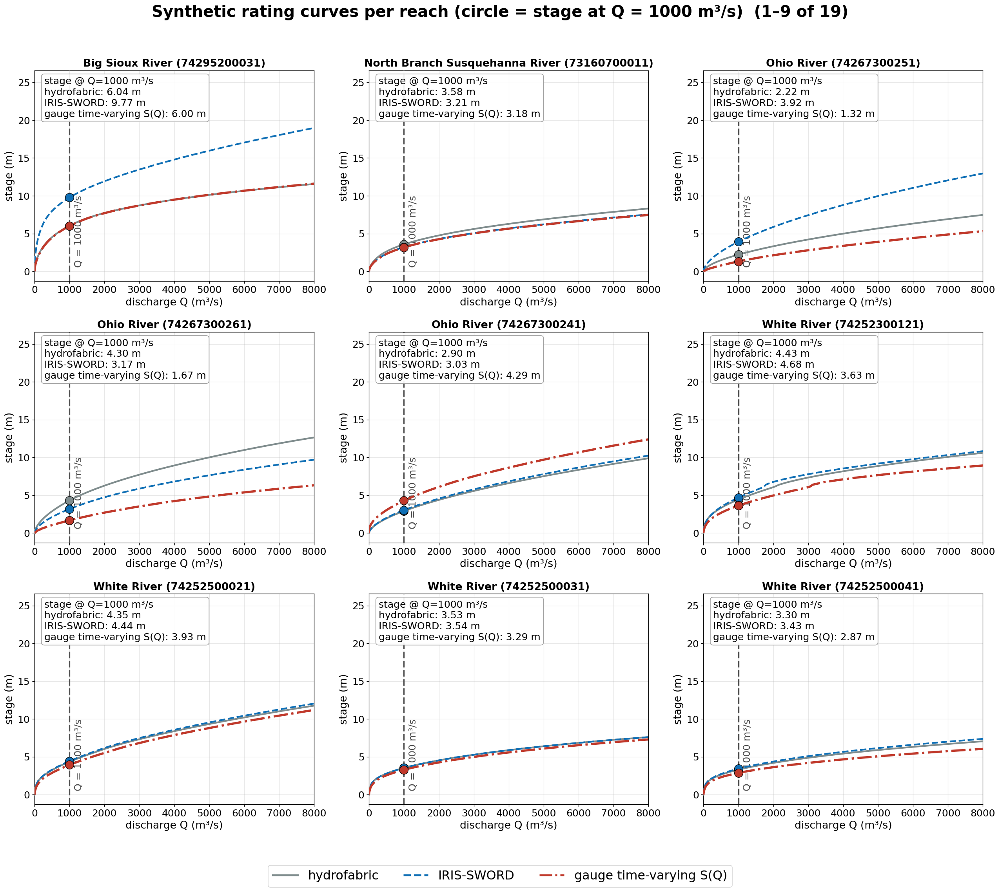

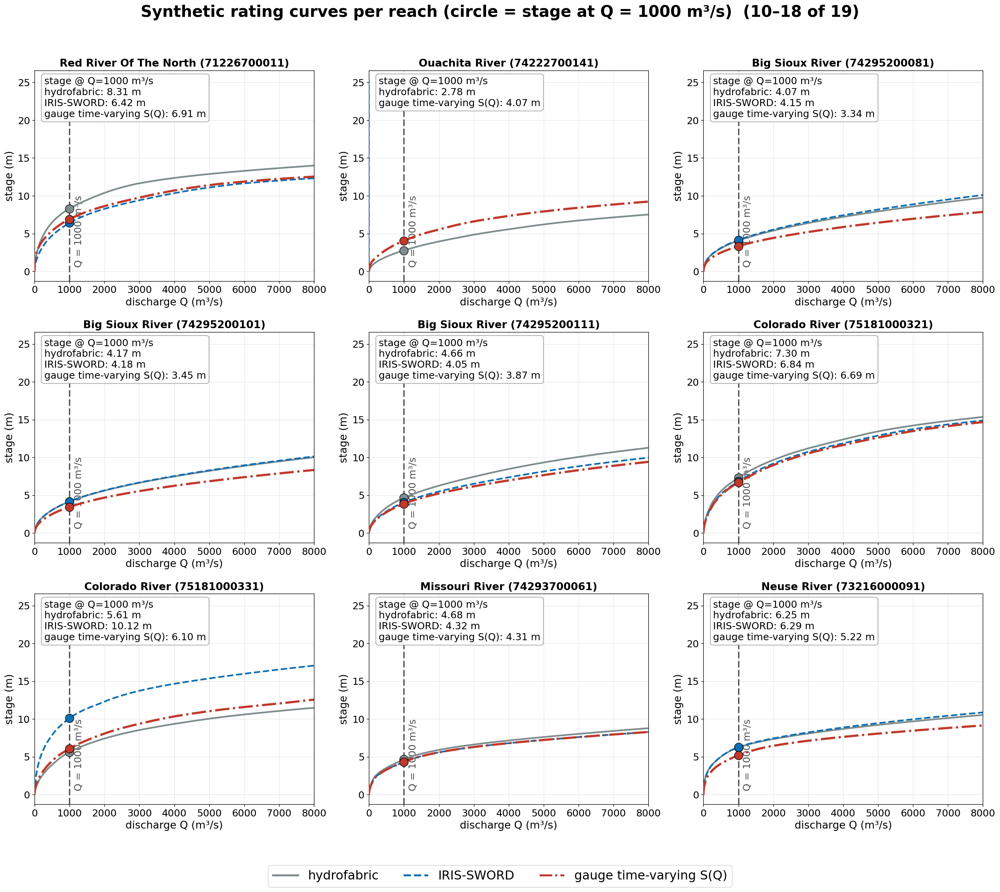

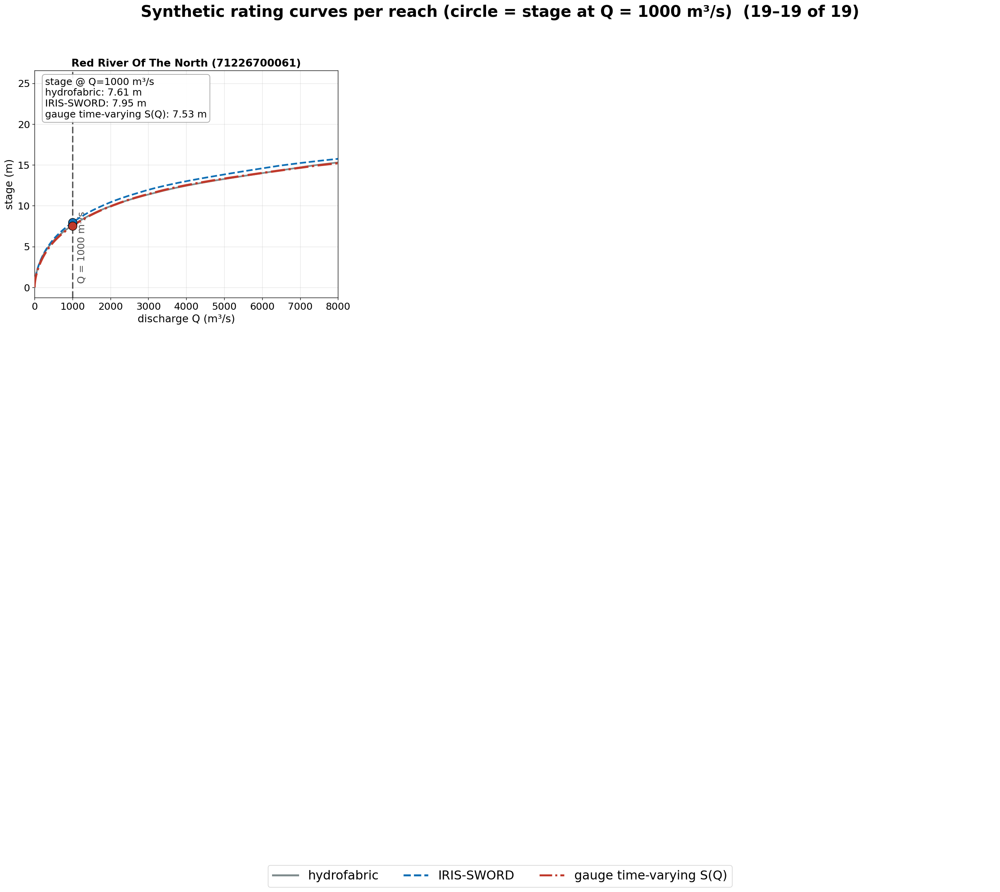

saved: ['src_grid_1.png', 'src_grid_2.png', 'src_grid_3.png']


In [13]:
def reach_src(reach, treat):
    "Per-treatment SRC (stage0, discharge_cms) saved by the FIM worker at injection time."
    f = FIMCACHE/f"reach{reach}_{treat}_src.csv"
    return pd.read_csv(f) if f.exists() else None

_src_reaches = [r for r in AREAS.reach if any((FIMCACHE/f"reach{r}_{t}_src.csv").exists() for t in TCOLOR)]
QSRC = 1000.0                                             # reference discharge: read the stage each SRC implies
def _stage_at_q(qarr, s0, qv=QSRC):
    qarr = np.asarray(qarr, float); s0 = np.asarray(s0, float); m = np.isfinite(qarr) & np.isfinite(s0)
    if m.sum() < 2 or qv > np.nanmax(qarr[m]) or qv < np.nanmin(qarr[m]): return np.nan
    o = np.argsort(qarr[m]); return float(np.interp(qv, qarr[m][o], s0[m][o]))
def _draw_src(ax, reach):
    row = ROWS[reach]; qmax = 0; sA = {}
    for t in ["hydrofabric", "iris_sword", "gauge_timevarying"]:
        g = reach_src(reach, t)
        if g is None or not len(g): continue
        lw = 3.4 if t == "gauge_timevarying" else 2.6
        ax.plot(g.discharge_cms, g.stage0, lw=lw, color=TCOLOR[t], ls=TSTYLE[t], zorder=5 if t == "gauge_timevarying" else 4)
        qmax = max(qmax, float(np.nanpercentile(g.discharge_cms, 96)))
        sA[t] = _stage_at_q(g.discharge_cms.values, g.stage0.values)
    xmax = min(max(qmax, QSRC*2.5), QSRC*8) if qmax > 0 else QSRC*2      # keep Q=1000 well inside the frame
    ax.set_xlim(0, xmax)
    ax.axvline(QSRC, color="0.30", ls=(0, (5, 2)), lw=2.0, zorder=3)     # vertical reference at Q=1000
    ax.annotate("Q = 1000 m³/s", (QSRC, 0), xytext=(7, 6), textcoords="offset points",
                rotation=90, ha="left", va="bottom", fontsize=15, color="0.30")
    lines = ["stage @ Q=1000 m³/s"]
    for t in ["hydrofabric", "iris_sword", "gauge_timevarying"]:
        if t in sA and sA[t] == sA[t]:
            ax.plot(QSRC, sA[t], "o", ms=13, mec="k", mew=.8, color=TCOLOR[t], zorder=7)   # circle where each SRC crosses Q=1000
            lines.append(f"{TLABEL[t]}: {sA[t]:.2f} m")
    ax.text(0.035, 0.97, "\n".join(lines), transform=ax.transAxes, ha="left", va="top", fontsize=15,
            bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=.93))     # upper-left = above the rising SRC (no overlap)
    ax.set_title(f"{row.river} ({reach})", fontsize=16); ax.set_xlabel("discharge Q (m³/s)", fontsize=16)
    ax.set_ylabel("stage (m)", fontsize=16); ax.tick_params(labelsize=15); ax.grid(alpha=.3)
_src_legend = [Line2D([],[],color=TCOLOR[t], ls=TSTYLE[t], lw=3, label=TLABEL[t]) for t in ["hydrofabric","iris_sword","gauge_timevarying"]]
if _src_reaches:
    _src_paths = grid_panels(_src_reaches, _draw_src, "src_grid",
                             "Synthetic rating curves per reach (circle = stage at Q = 1000 m³/s)", _src_legend, legend_ncol=3)
    print("saved:", [p.name for p in _src_paths])
else:
    print("No FIM yet - set env TVS_REGEN=1 (Step 6) to populate SRC / agreement / CSI.")


## Deliverable 3 · Inundation agreement maps - 3×3 panels

Hit / miss / false-alarm map of the **gauge time-varying** FIM vs. the FIMBench benchmark, over the **River Mask**
(the reach's NWM catchments; benchmark cleaned to its largest connected component). Following the work6 house
style: TP red, FP green, FN blue over a light CARTO Positron basemap, with the CSI / POD / FAR in each title and a
shared legend below.

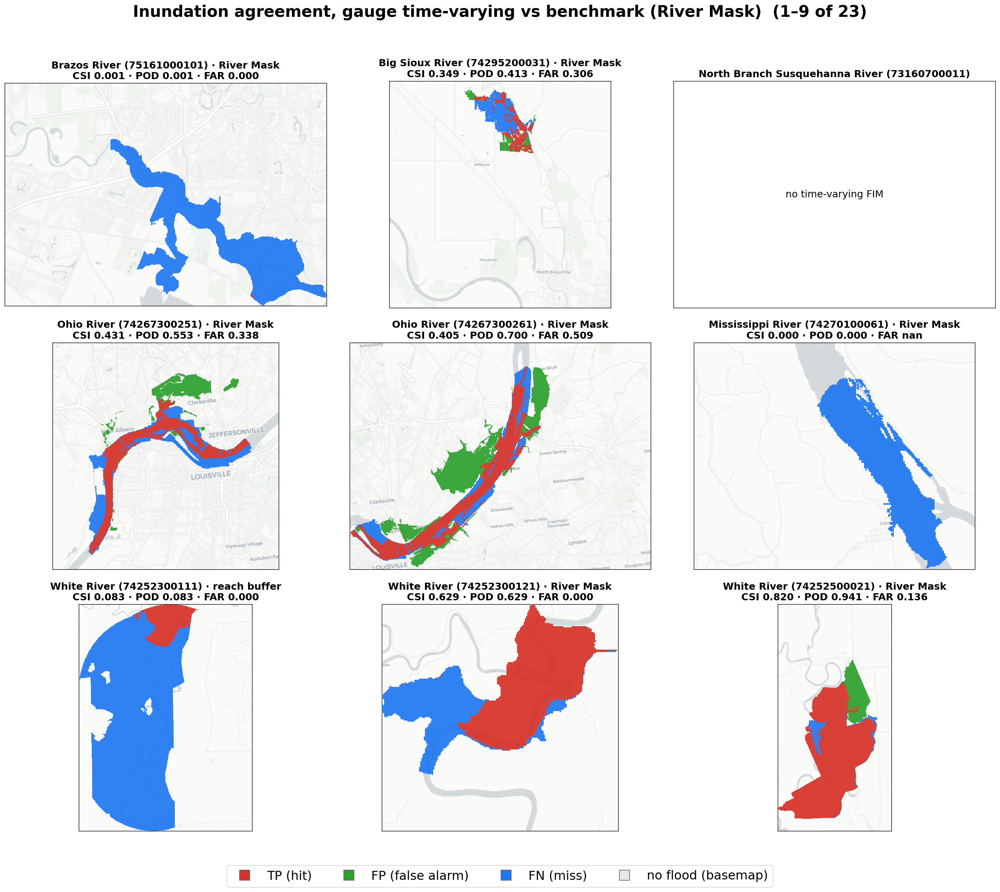

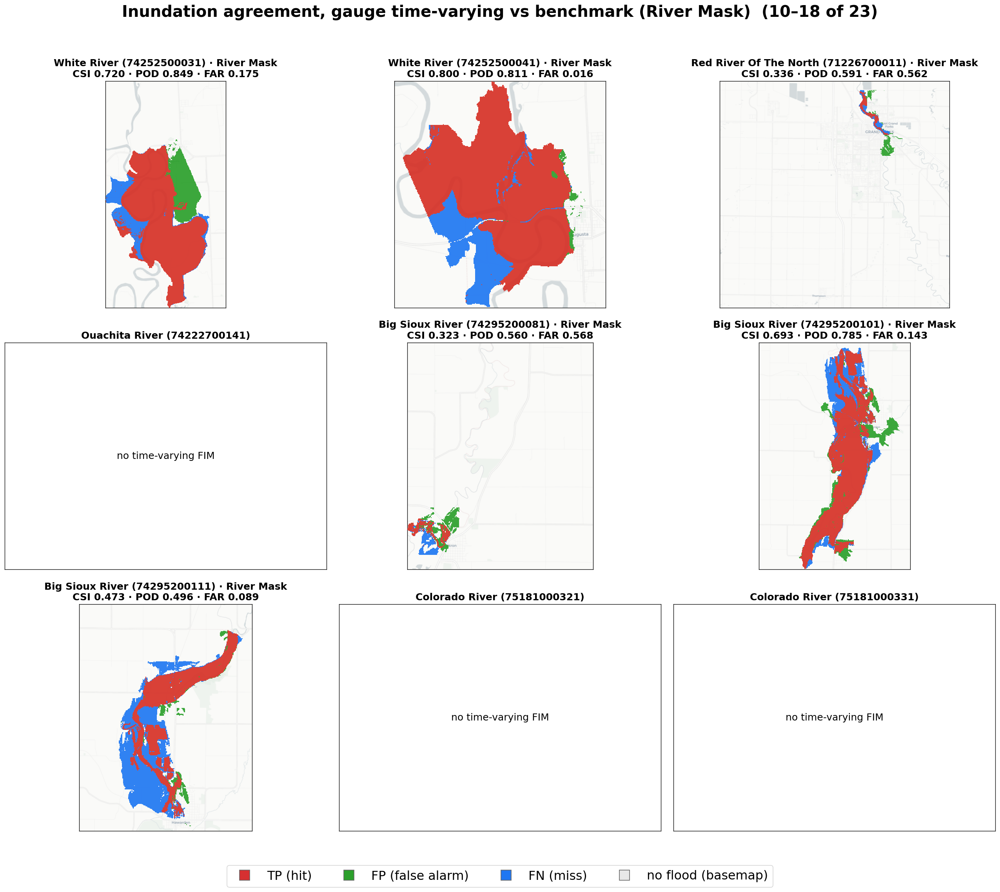

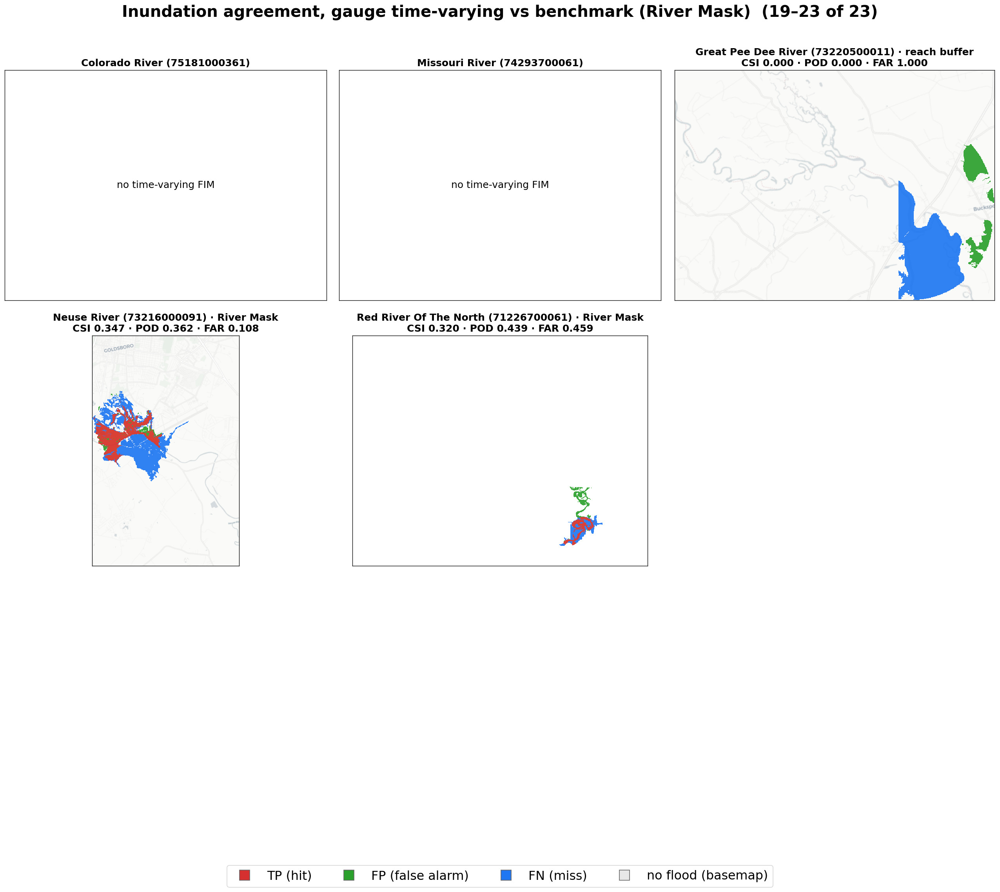

saved: ['agreement_grid_1.png', 'agreement_grid_2.png', 'agreement_grid_3.png']


In [14]:
from scipy import ndimage as _ndi2
try: import contextily as _cx; _HAVE_CX = True
except Exception: _HAVE_CX = False
_RGBA = {2:(0.84,0.19,0.15,0.92), 1:(0.17,0.63,0.17,0.92), -1:(0.12,0.47,0.95,0.92), 0:(0,0,0,0)}  # TP red, FP green, FN blue, TN transparent

def _draw_agree(ax, reach):
    row = ROWS[reach]; bm, _ = bench_paths(row)
    geom = river_mask(_aoi_dir(row.huc8.split(";")[0]), reach); dom = "River Mask"
    tif = FIMCACHE/f"reach{reach}_gauge_timevarying.tif"
    if not (tif.exists() and bm):
        ax.text(.5,.5,"no time-varying FIM", ha="center", va="center", fontsize=15); ax.set_title(f"{row.river} ({reach})", fontsize=15)
        ax.set_xticks([]); ax.set_yticks([]); return
    res = score_rm(str(tif), bm, geom, return_grid=True) if geom is not None else (None,)*4
    if res[0] is None or (res[3] or {}).get("bm_wet_km2", 0) == 0:           # mask empty -> 5 km reach-buffer fallback
        geom = reach_buffer_geom(reach, 5.0); dom = "reach buffer"
        res = score_rm(str(tif), bm, geom, return_grid=True) if geom is not None else (None,)*4
    if res[0] is None:
        ax.text(.5,.5,"no benchmark overlap", ha="center", va="center", fontsize=14); ax.set_title(f"{row.river} ({reach})", fontsize=15)
        ax.set_xticks([]); ax.set_yticks([]); return
    cat, tr, b, m = res
    ax.set_xlim(b[0], b[2]); ax.set_ylim(b[1], b[3])
    if _HAVE_CX:
        try: _cx.add_basemap(ax, source=_cx.providers.CartoDB.Positron, crs="EPSG:5070", attribution=False, zorder=1)
        except Exception: pass
    rgba = np.zeros((*cat.shape, 4))
    for v, c in _RGBA.items(): rgba[cat == v] = c
    ax.imshow(rgba, extent=[b[0],b[2],b[1],b[3]], origin="upper", zorder=4, interpolation="nearest")
    ax.set_title(f"{row.river} ({reach}) · {dom}\nCSI {m.get('CSI',np.nan):.3f} · POD {m.get('POD',np.nan):.3f} · FAR {m.get('FAR',np.nan):.3f}", fontsize=15)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
_agree_reaches = [r for r in AREAS.reach if (FIMCACHE/f"reach{r}_gauge_timevarying.tif").exists()]
_agree_legend = [Line2D([],[],marker="s",ls="",ms=16,mfc=c,mec="0.4",label=l)
                 for c,l in [("#d63031","TP (hit)"),("#2ca02c","FP (false alarm)"),("#1f77f2","FN (miss)"),("#e8e8e8","no flood (basemap)")]]
if _agree_reaches:
    _ap = grid_panels(_agree_reaches, _draw_agree, "agreement_grid",
                      "Inundation agreement, gauge time-varying vs benchmark (River Mask)", _agree_legend, legend_ncol=4)
    print("saved:", [p.name for p in _ap])
else:
    print("No time-varying FIM tifs yet (see Step 6).")


## Deliverable 4 · CSI / F1 skill vs. IRIS-SWORD - 3×3 bar panels

Per reach: CSI (blue) and F1 (orange) for each slope treatment (value labels on the bars), with a **gold star** on
the best CSI and a **red star** on the best F1. IRIS-SWORD (Chen 2025) is the reference treatment the gauge
time-varying method is compared against. Shared legend below.

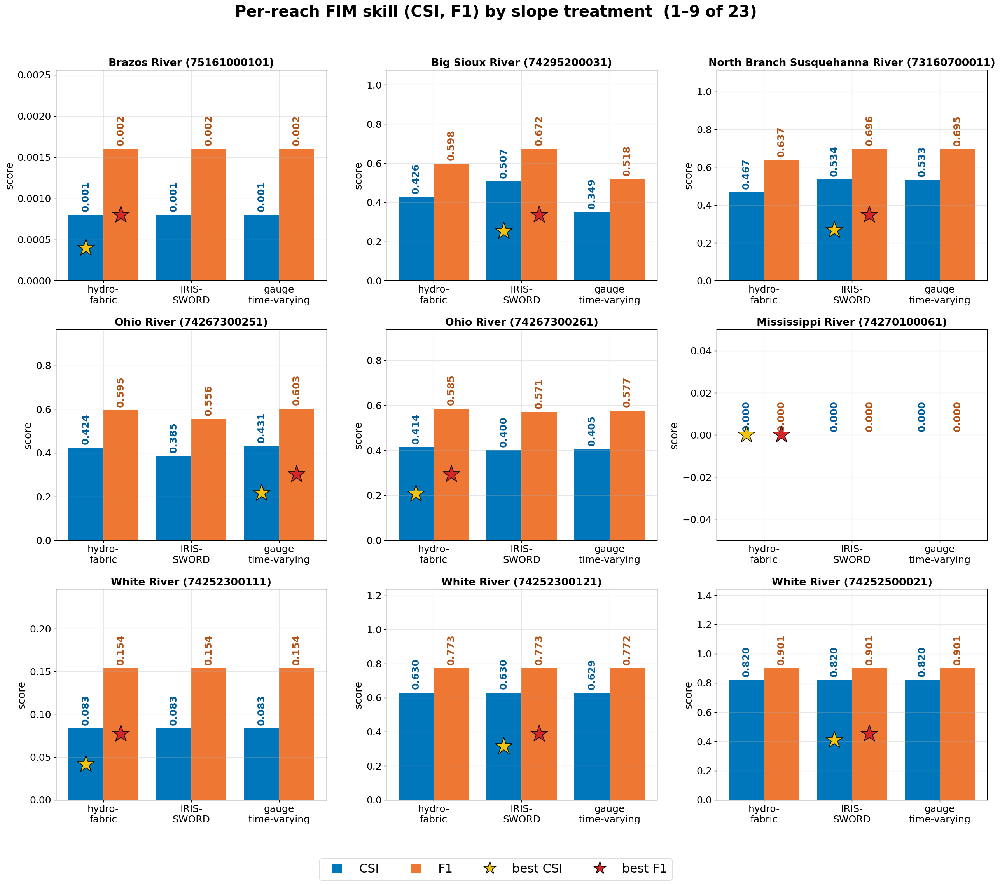

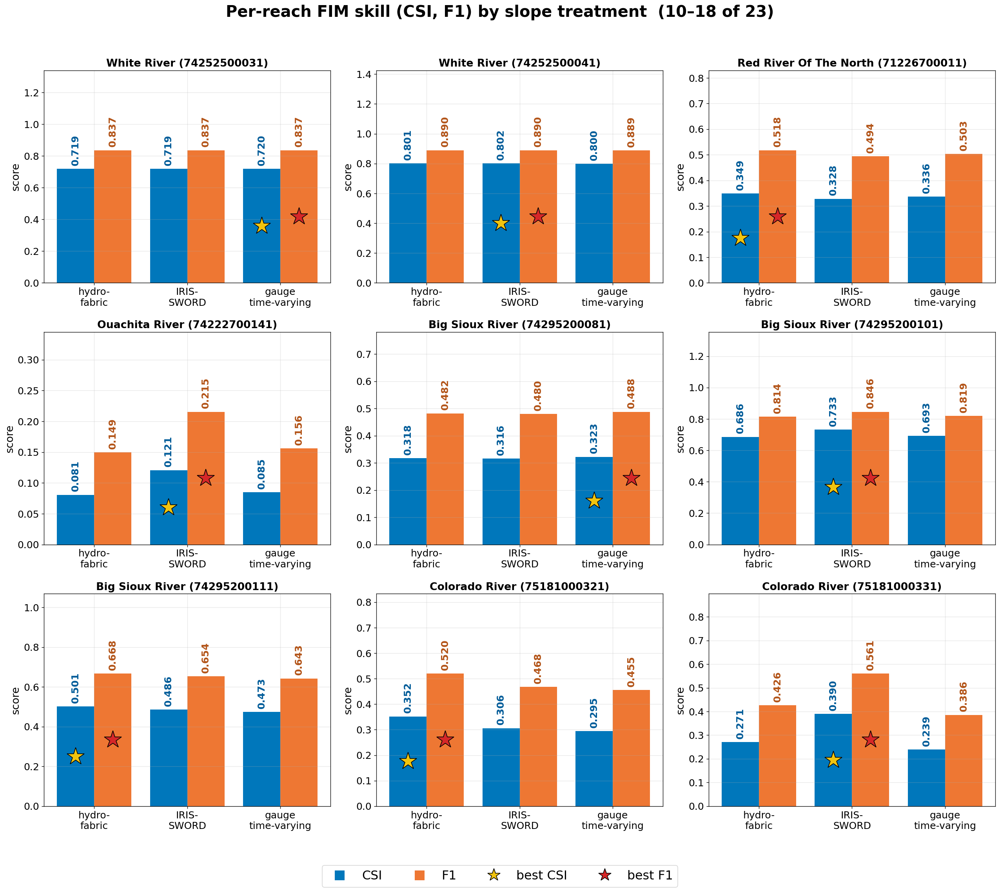

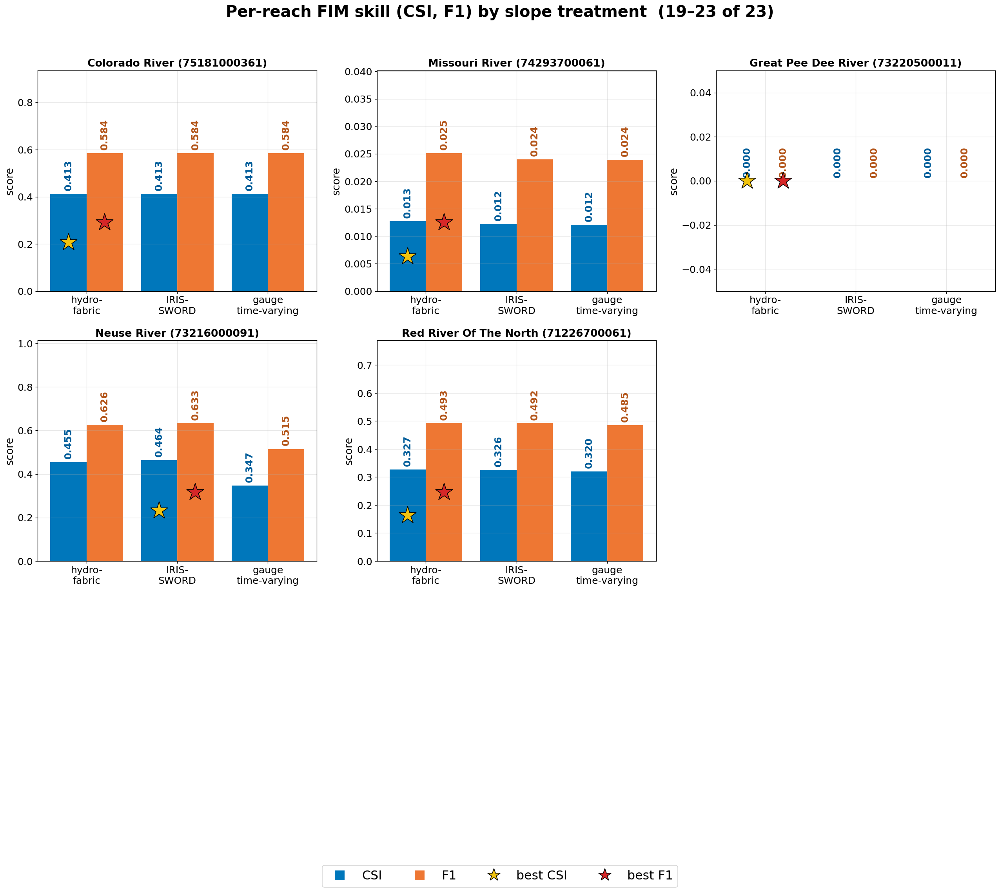

saved: ['csi_f1_grid_1.png', 'csi_f1_grid_2.png', 'csi_f1_grid_3.png']


In [15]:
_BARLBL = {"hydrofabric":"hydro-\nfabric", "iris_sword":"IRIS-\nSWORD", "gauge_timevarying":"gauge\ntime-varying"}
def _draw_bars(ax, reach):
    row = ROWS[reach]; sc = SCORES[SCORES.reach.astype(str)==reach]
    sc = sc[sc.CSI.notna()] if "CSI" in sc else sc
    if not len(sc):
        ax.text(.5,.5,"no scores", ha="center", va="center", fontsize=15); ax.set_title(f"{row.river} ({reach})", fontsize=15)
        ax.set_xticks([]); ax.set_yticks([]); return
    order = [t for t in ["hydrofabric","iris_sword","gauge_timevarying"] if t in set(sc.treatment)]
    x = np.arange(len(order)); w = 0.4
    csi = np.array([float(sc[sc.treatment==t].CSI.iloc[0]) for t in order])
    f1  = np.array([float(sc[sc.treatment==t].F1.iloc[0]) if "F1" in sc else np.nan for t in order])
    ax.bar(x-0.2, csi, w, color="#0077bb"); ax.bar(x+0.2, f1, w, color="#ee7733")
    for xi, cv, fv in zip(x, csi, f1):
        if cv==cv: ax.annotate(f"{cv:.3f}", (xi-0.2, cv), xytext=(0,5), textcoords="offset points", ha="center", va="bottom", fontsize=15, rotation=90, color="#005c99", fontweight="bold")
        if fv==fv: ax.annotate(f"{fv:.3f}", (xi+0.2, fv), xytext=(0,5), textcoords="offset points", ha="center", va="bottom", fontsize=15, rotation=90, color="#b35418", fontweight="bold")
    if np.isfinite(csi).any(): ax.plot(x[np.nanargmax(csi)]-0.2, np.nanmax(csi)/2, "*", color="#f1c40f", ms=28, mec="k", zorder=7)
    if np.isfinite(f1).any():  ax.plot(x[np.nanargmax(f1)]+0.2, np.nanmax(f1)/2, "*", color="#d62728", ms=28, mec="k", zorder=7)
    ax.set_xticks(x); ax.set_xticklabels([_BARLBL.get(t,t) for t in order], fontsize=15)
    ax.set_ylim(0, max(np.nanmax(csi) if np.isfinite(csi).any() else .1, np.nanmax(f1) if np.isfinite(f1).any() else .1)*1.6)
    ax.set_title(f"{row.river} ({reach})", fontsize=16); ax.set_ylabel("score", fontsize=16); ax.tick_params(axis="y", labelsize=15); ax.grid(axis="y", alpha=.3)
_bar_reaches = [r for r in AREAS.reach if len(SCORES[(SCORES.reach.astype(str)==r) & (SCORES.CSI.notna() if 'CSI' in SCORES else False)])] if len(SCORES) else []
_bar_legend = [Line2D([],[],marker="s",ls="",ms=15,mfc="#0077bb",mec="none",label="CSI"),
               Line2D([],[],marker="s",ls="",ms=15,mfc="#ee7733",mec="none",label="F1"),
               Line2D([],[],marker="*",ls="",ms=20,mfc="#f1c40f",mec="k",label="best CSI"),
               Line2D([],[],marker="*",ls="",ms=20,mfc="#d62728",mec="k",label="best F1")]
if _bar_reaches:
    _bp = grid_panels(_bar_reaches, _draw_bars, "csi_f1_grid",
                      "Per-reach FIM skill (CSI, F1) by slope treatment", _bar_legend, legend_ncol=4)
    print("saved:", [p.name for p in _bp])
else:
    print("No scores yet (see Step 6).")


## Evaluation domain: CSI **before vs after** the River Mask

Quantifying what the River Mask buys us, on the same local footprint, for **a few illustrative cases** (the
reaches where masking changes CSI most). **Before** = the reach's local bounding box including all benchmark water
(off-channel lake / tributary / urban water that HAND-FIM cannot model), with no connected-component cleaning.
**After** = the River-Mask domain (the reach's NWM catchments) with the benchmark cleaned to its largest connected
component. Where multi-source off-channel water is present the River Mask lifts CSI substantially; where the local
box is already channel-dominated it barely moves. **All other reaches simply use the River-Mask CSI directly**
(Deliverable 4).

*(The naive whole-benchmark-AOI domain is unbounded for the 0.5 m optical/SAR tiles and is not scored here; the
bounding box is the tractable, like-for-like stand-in for "before masking".)*

Illustrative cases (n=4 reaches): mean CSI 0.394 (before) -> 0.561 (River Mask), gain +0.167
All 23 scored reaches use the River-Mask CSI directly (Deliverable 4).


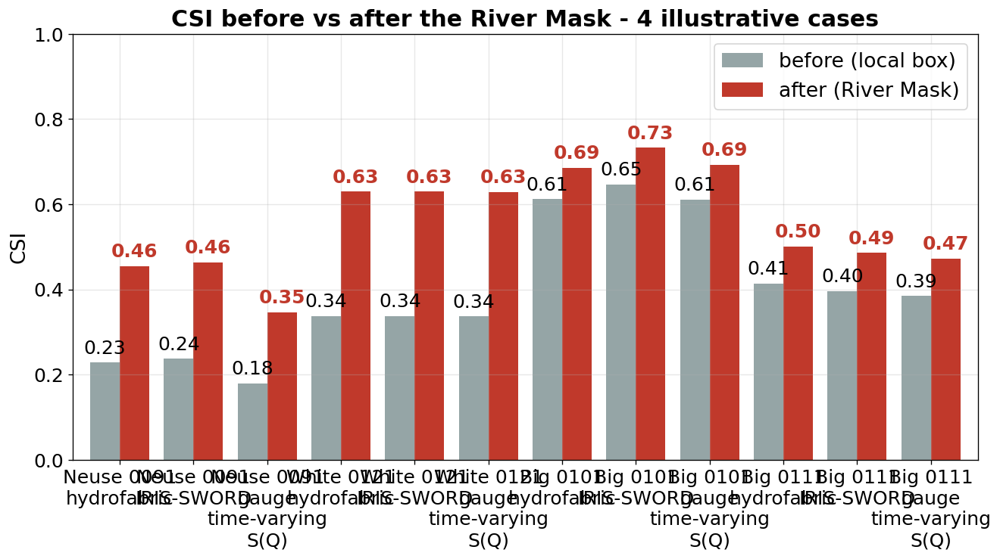

,reach,river,treatment,CSI_before_box,CSI_after_rivermask,delta
0,73216000091,Neuse River,hydrofabric,0.229,0.455,0.226
1,73216000091,Neuse River,iris_sword,0.237,0.464,0.227
2,73216000091,Neuse River,gauge_timevarying,0.180,0.347,0.167
3,74252300121,White River,hydrofabric,0.338,0.630,0.291
4,74252300121,White River,iris_sword,0.338,0.630,0.292
5,74252300121,White River,gauge_timevarying,0.337,0.629,0.292
6,74295200101,Big Sioux River,hydrofabric,0.612,0.686,0.074
7,74295200101,Big Sioux River,iris_sword,0.647,0.733,0.085
8,74295200101,Big Sioux River,gauge_timevarying,0.611,0.693,0.083
9,74295200111,Big Sioux River,hydrofabric,0.414,0.501,0.088


In [16]:
from shapely.geometry import box as _box_geom
def csi_before(row, tif, mask):
    "CSI on the reach's local bounding box, benchmark NOT connected-component-cleaned = the pre-mask domain."
    bm, _ = bench_paths(row)
    if mask is None or not (tif and Path(tif).exists() and bm): return np.nan
    bb = _box_geom(*mask.bounds)                         # rectangular local footprint (incl. off-channel water)
    return score_rm(str(tif), bm, bb, largest_cc=False).get("CSI", np.nan)

cmp_rows = []
_scored = sorted(set(SCORES[SCORES.CSI.notna()].reach.astype(str))) if len(SCORES) and "CSI" in SCORES else []
for reach in _scored:
    row = ROWS[reach]; mask = river_mask(_aoi_dir(row.huc8.split(";")[0]), reach); bm, _ = bench_paths(row)
    for t in TREATMENTS:
        tif = FIMCACHE/f"reach{reach}_{t}.tif"
        if not tif.exists(): continue
        before = csi_before(row, tif, mask)
        after  = score_rm(str(tif), bm, mask).get("CSI", np.nan) if mask is not None else np.nan
        cmp_rows.append(dict(reach=reach, river=row.river, treatment=t,
                             CSI_before_box=round(before,3) if before==before else np.nan,
                             CSI_after_rivermask=round(after,3) if after==after else np.nan,
                             delta=round((after-before),3) if (after==after and before==before) else np.nan))
N_EXAMPLES = 4                                       # how many illustrative reaches to show in the before/after table
CMP = pd.DataFrame(cmp_rows)
if len(CMP):
    CMP.to_csv(OUT/"csi_before_after_rivermask.csv", index=False)   # full comparison saved for reference
    # pick the example reaches = those where masking changes CSI most (largest mean |delta|)
    rank = CMP.assign(absd=CMP.delta.abs()).groupby("reach").absd.mean().sort_values(ascending=False)
    examples = list(rank.head(N_EXAMPLES).index)
    EX = CMP[CMP.reach.isin(examples)].reset_index(drop=True)
    _mb, _ma = EX.CSI_before_box.mean(), EX.CSI_after_rivermask.mean()
    print(f"Illustrative cases (n={EX.reach.nunique()} reaches): mean CSI {_mb:.3f} (before) -> {_ma:.3f} (River Mask), gain {_ma-_mb:+.3f}")
    print(f"All {CMP.reach.nunique()} scored reaches use the River-Mask CSI directly (Deliverable 4).")
    fig, ax = plt.subplots(figsize=(max(11, len(EX)*0.95), 6.5))
    x = np.arange(len(EX)); w = 0.4
    ax.bar(x-w/2, EX.CSI_before_box, w, color="#95a5a6", label="before (local box)")
    ax.bar(x+w/2, EX.CSI_after_rivermask, w, color="#c0392b", label="after (River Mask)")
    for xi, bv, av in zip(x, EX.CSI_before_box, EX.CSI_after_rivermask):
        if bv==bv: ax.annotate(f"{bv:.2f}", (xi-w/2, bv), xytext=(0,4), textcoords="offset points", ha="center", va="bottom", fontsize=15)
        if av==av: ax.annotate(f"{av:.2f}", (xi+w/2, av), xytext=(0,4), textcoords="offset points", ha="center", va="bottom", fontsize=15, color="#c0392b", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels([f"{ROWS[r].river.split()[0]} {r[-4:]}\n{TLABEL[t].replace(' ',chr(10))}" for r,t in zip(EX.reach, EX.treatment)], rotation=0, fontsize=15)
    ax.set_ylabel("CSI", fontsize=16); ax.set_ylim(0, 1); ax.set_title(f"CSI before vs after the River Mask - {EX.reach.nunique()} illustrative cases", fontsize=18)
    ax.tick_params(labelsize=15); ax.legend(loc="upper right", fontsize=16); ax.margins(x=0.02); fig.tight_layout()
    savefig(fig, FIGS/"csi_before_after_rivermask.png"); plt.show()
    display(EX)
else:
    print("No scored reaches yet - run Step 6 (TVS_REGEN=1) first.")


## Notes and outlook

- **Deliverable 1** (`S(Q)` relationships) is computed for every reach with sufficient paired-gauge data and is
  independent of the FIM pipeline.
- **Deliverables 2–4** require the HAND-FIM pipeline in Step 6. Set env `TVS_REGEN=1` and `TVS_SUBSET=reach,reach`
  to generate a subset first (verify end-to-end), then expand to all reaches. All engine code is inlined so the
  notebook runs standalone in `fimserve`.
- **Evaluation** follows the *River Mask* protocol: metrics are computed only on the reach's NWM catchments, with
  the benchmark cleaned to its largest connected component - isolating the region where the reach slope can
  actually change the inundation, instead of letting off-channel lake/urban water suppress the signal.

### Outlook - time-varying slope for *water mapping*, not only flood inundation

River slope is a **dynamic** component of the flow, yet the operational HAND-FIM builds its synthetic rating
curves from a **static** slope. This study makes the slope flow-dependent, `S = S(Q)`, which is a more physical
rating and a direct improvement for **flood inundation mapping**. The same idea extends naturally to **water
surface / water-extent mapping**: because the water-surface slope steepens on the rising limb and flattens in
backwater, a time-varying slope should track the wetted width and water-surface elevation through an event more
faithfully than a single fixed slope. A promising next step is to drive the time-varying SRC with the near-real-time
gauge (or SWOT) slope to produce **event-resolved water maps**, and to validate them against the same River-Mask
benchmark domain used here.